## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "Base"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [4]:
override = False
use_preds = True
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,0.213783
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,0.219060
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,0.236789
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,0.242293
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,0.257918
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,2.156549
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,2.175802
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,2.194514
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,2.215902


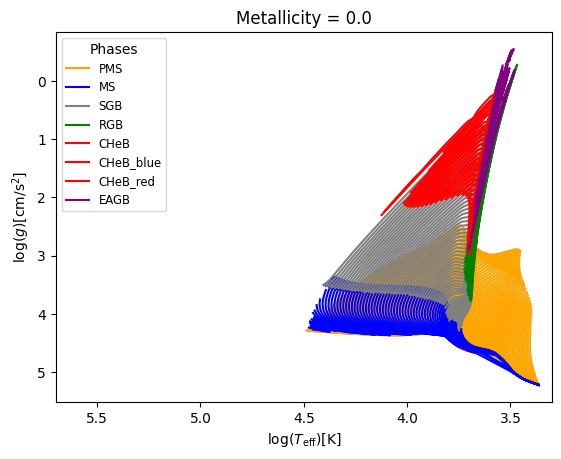

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,0.535041
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,0.535800
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,0.536558
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,0.514282
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,0.537441
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,1.005181
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,1.005609
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,1.006466
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,1.006894


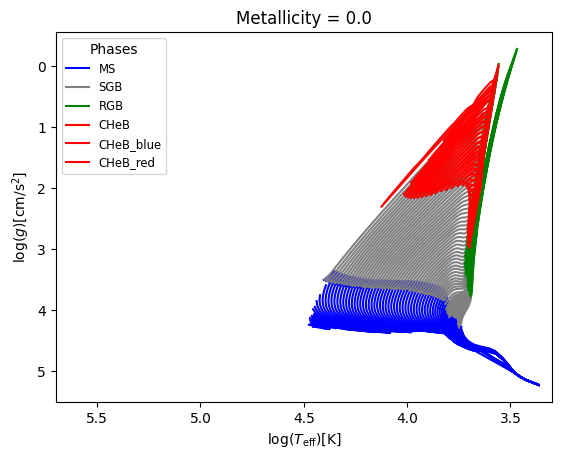

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : -0.98 - 2.8373, Mean : 0.9648, Median : 1.0158



In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [9]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.7140803707653656
  RMSE :  1.6260706065843913
  MAE :  1.3562018118194228
  MedAE :  1.2151522118086535
  CORR :  0.8773843227443292
  MAX_ER :  5.809022809397376
  Percentiles : 
    75th percentile :  1.9209920410806551
    90th percentile :  2.507425570052078
    95th percentile :  2.947770833345188
    99th percentile :  4.134527222987911

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.8170987684749786
  RMSE :  1.4568068548859194
  MAE :  1.0807392493061083
  MedAE :  0.878467562354595
  CORR :  0.9105157535025173
  MAX_ER :  5.531744924052422
  Percentiles : 
    75th percentile :  1.1846194187033374
    90th percentile :  2.1507340911387933
    95th percentile :  3.4273555307651735
    99th percentile :  4.822304718582632

mass results for the label category with a value of 3.0
  value 

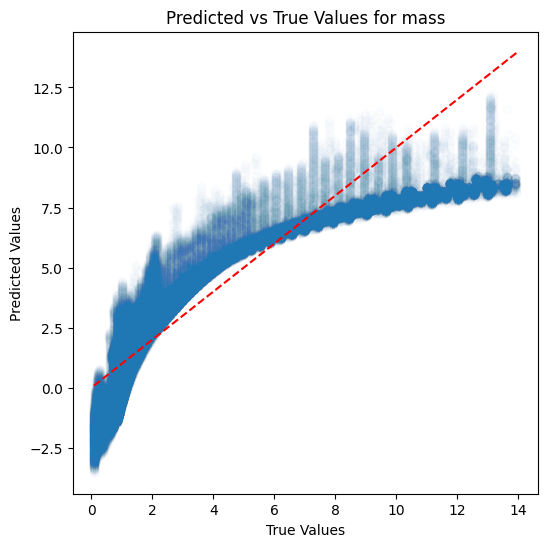

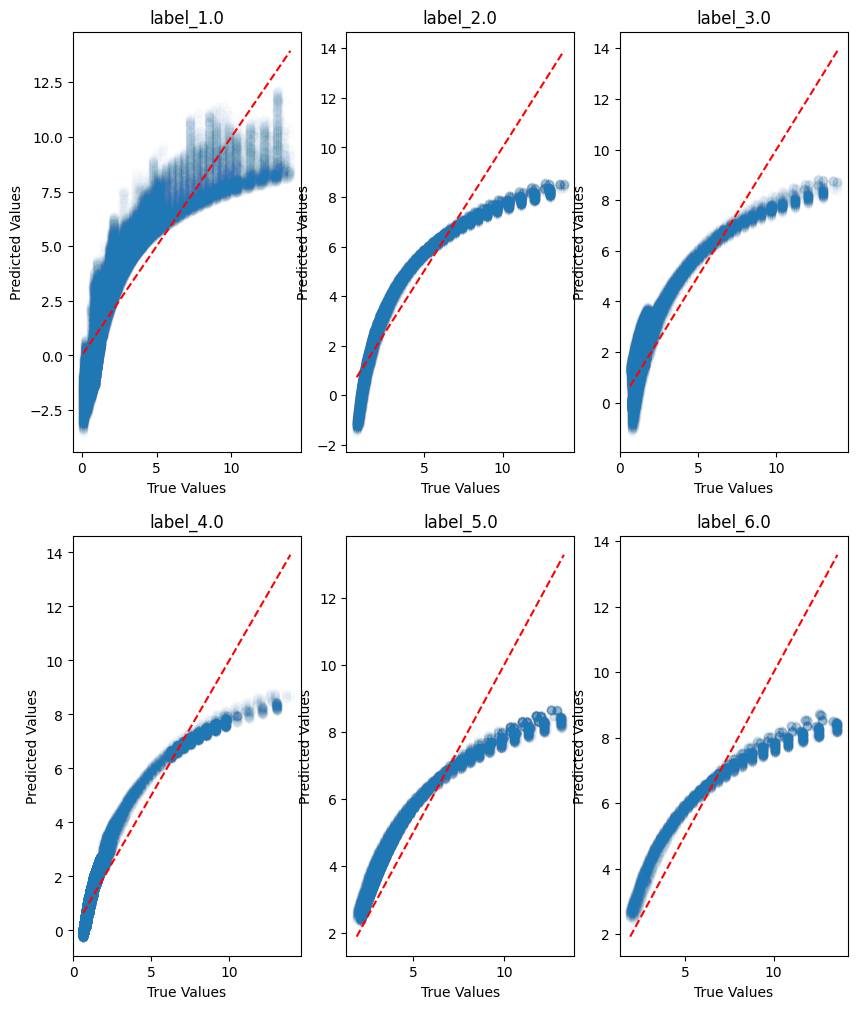

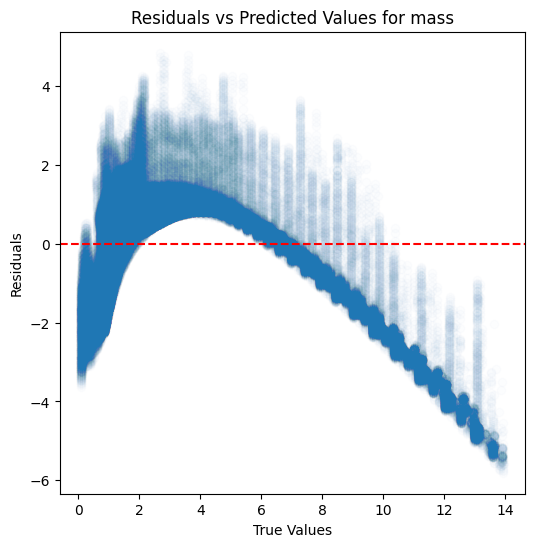

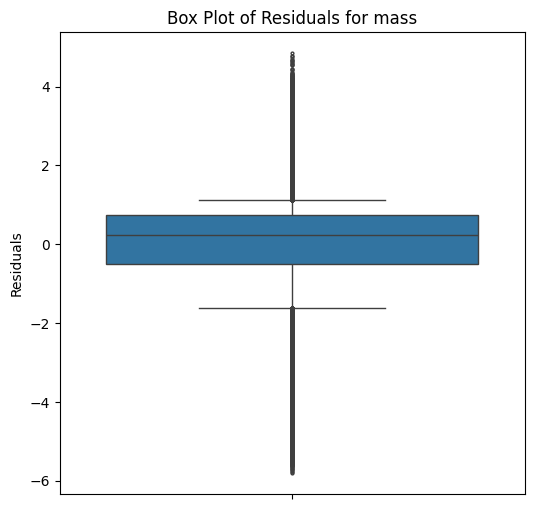

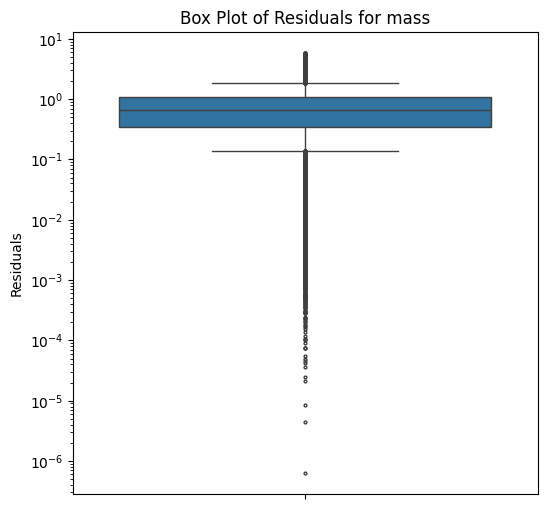

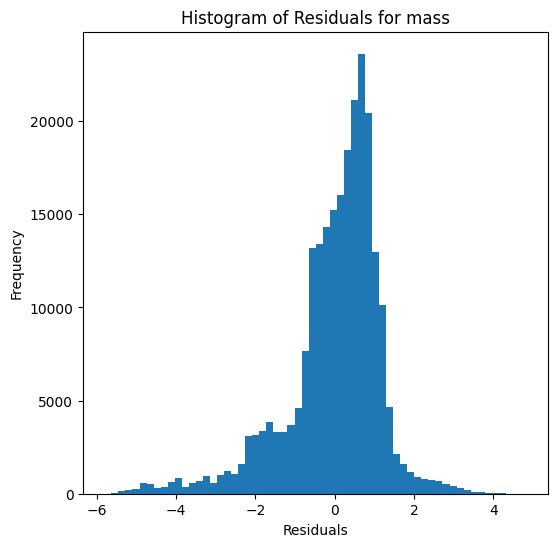

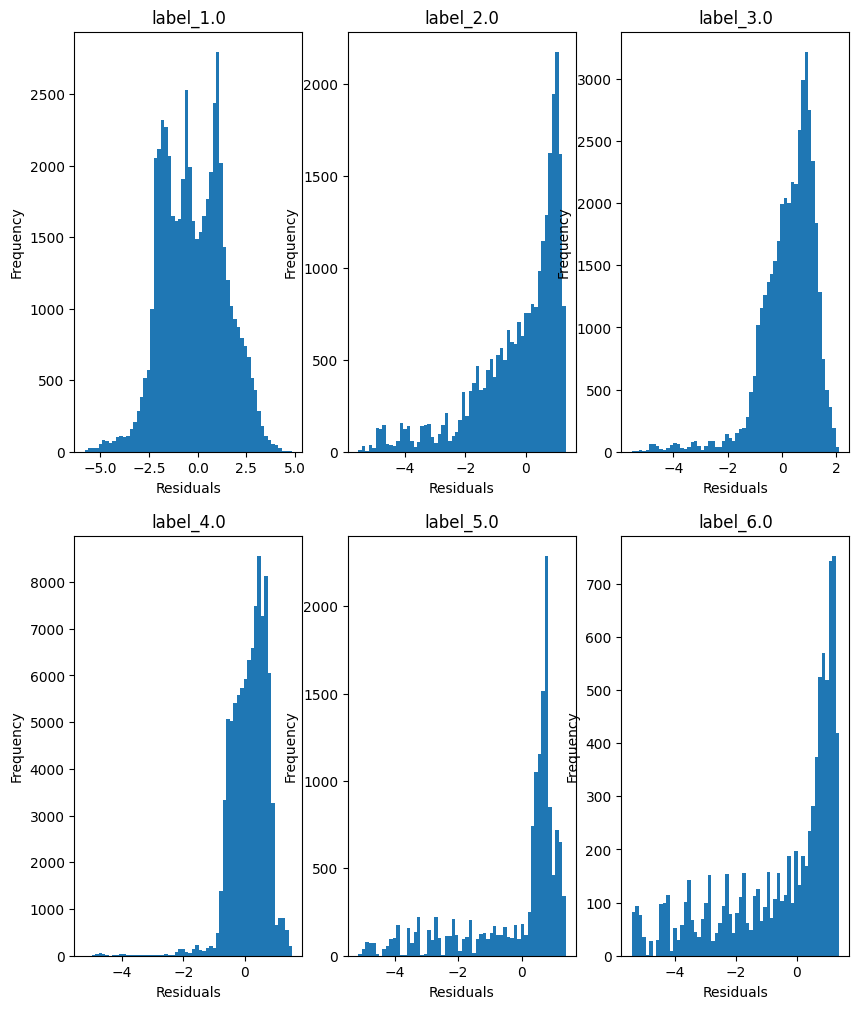

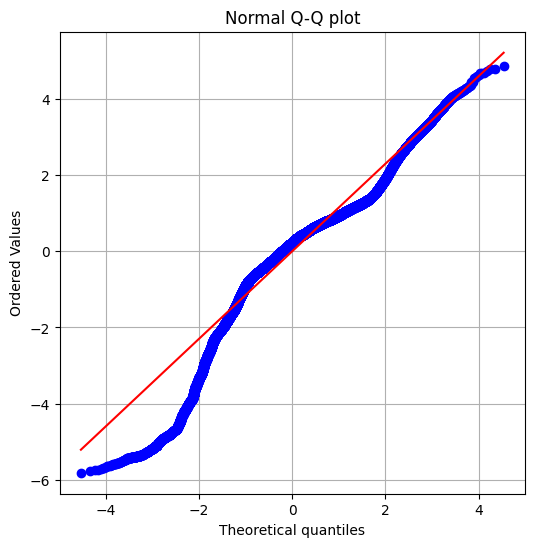

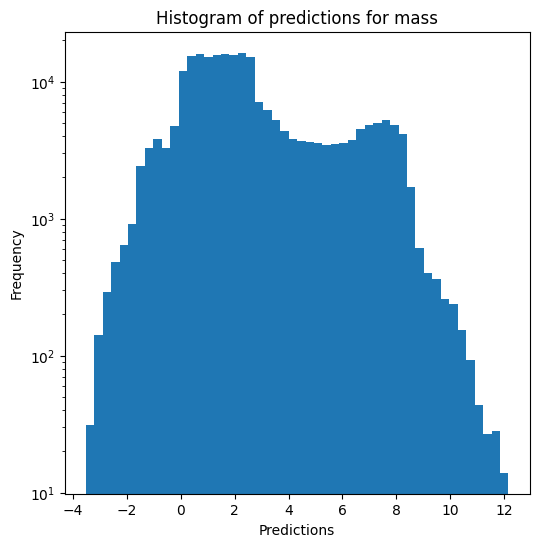

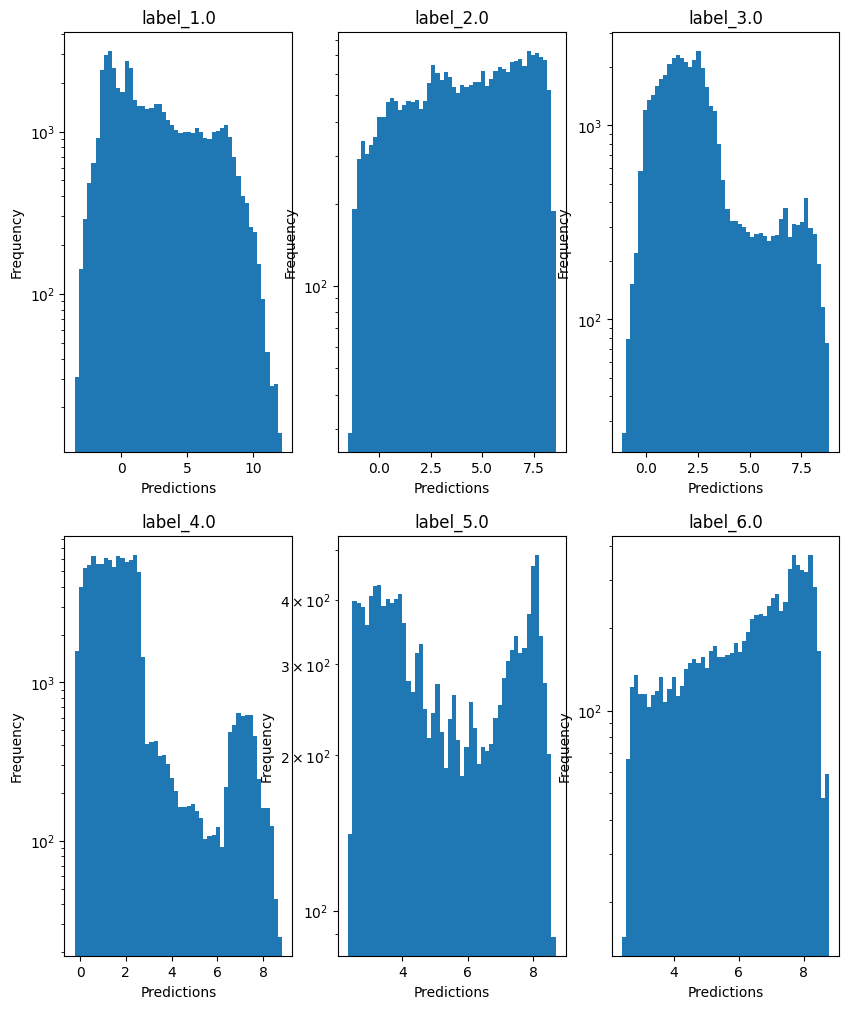

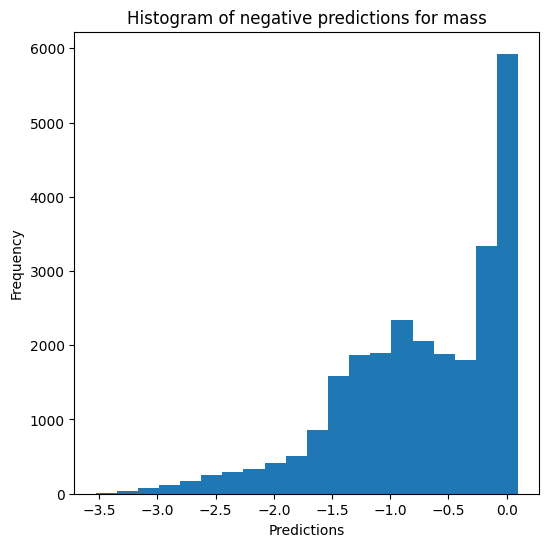


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9484107826824842
  RMSE :  0.08328587325029292
  MAE :  0.06347474231030695
  MedAE :  0.05315497875555691
  CORR :  0.973870221001157
  MAX_ER :  0.3506672434969049
  Percentiles : 
    75th percentile :  0.08970545471748137
    90th percentile :  0.11906427683739637
    95th percentile :  0.16799917501819916
    99th percentile :  0.2684041042258655

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9977700166955076
  RMSE :  0.038903834702896725
  MAE :  0.030590827136313413
  MedAE :  0.025142574806447715
  CORR :  0.9991018210196535
  MAX_ER :  0.115891857446936
  Percentiles : 
    75th percentile :  0.04434843035675645
    90th percentile :  0.06665784034114298
    95th percentile :  0.07914560411334012
    99th percentile :  0.09843326758116168

radius results for the label cate

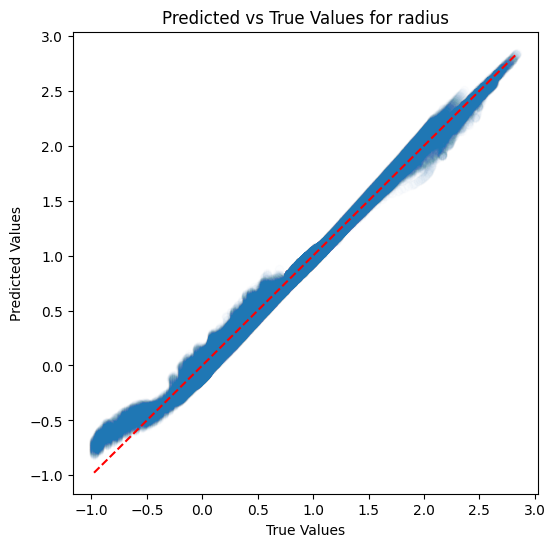

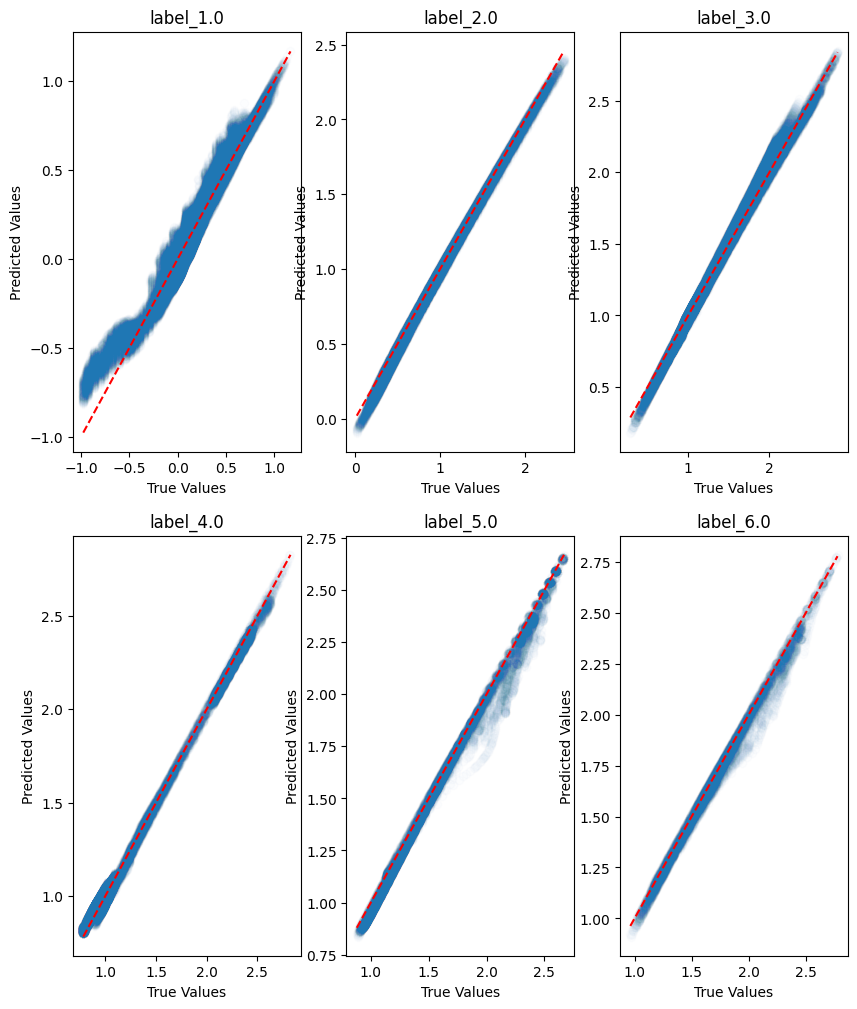

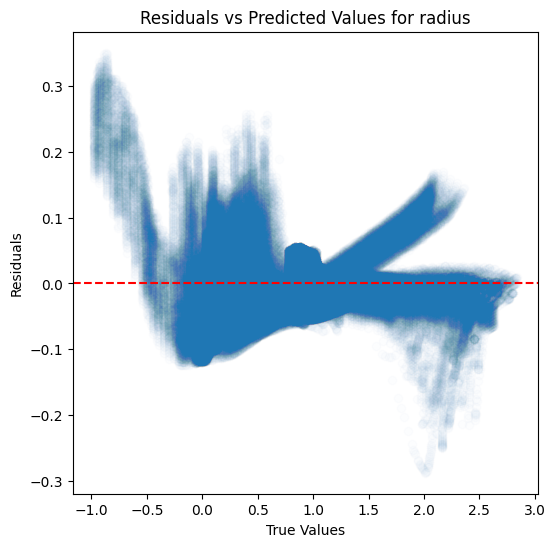

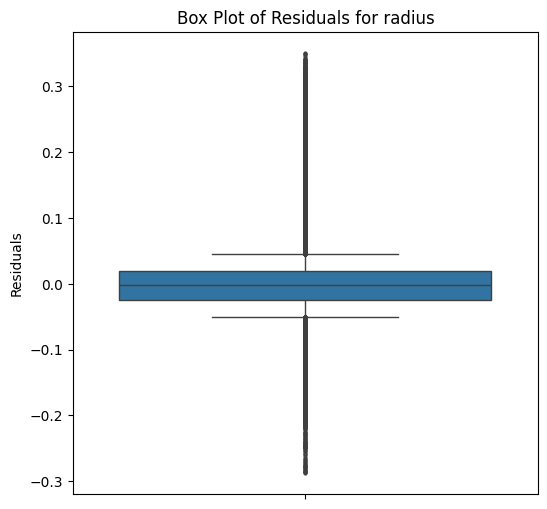

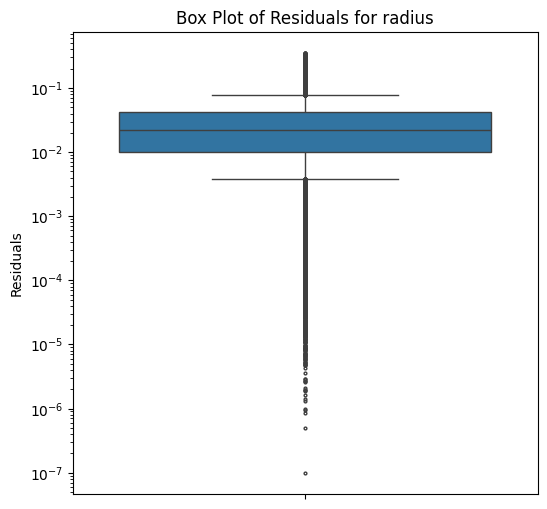

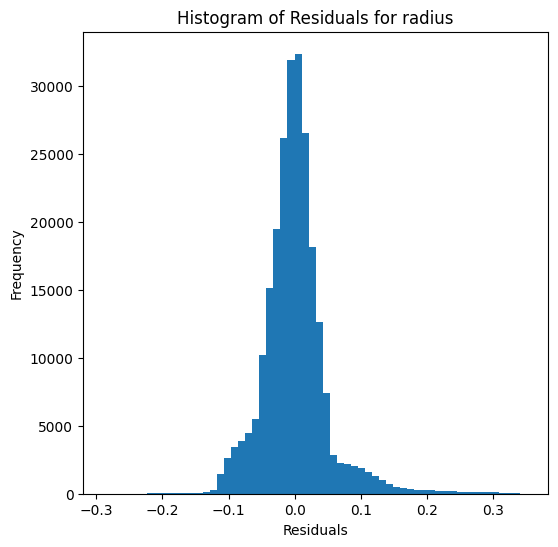

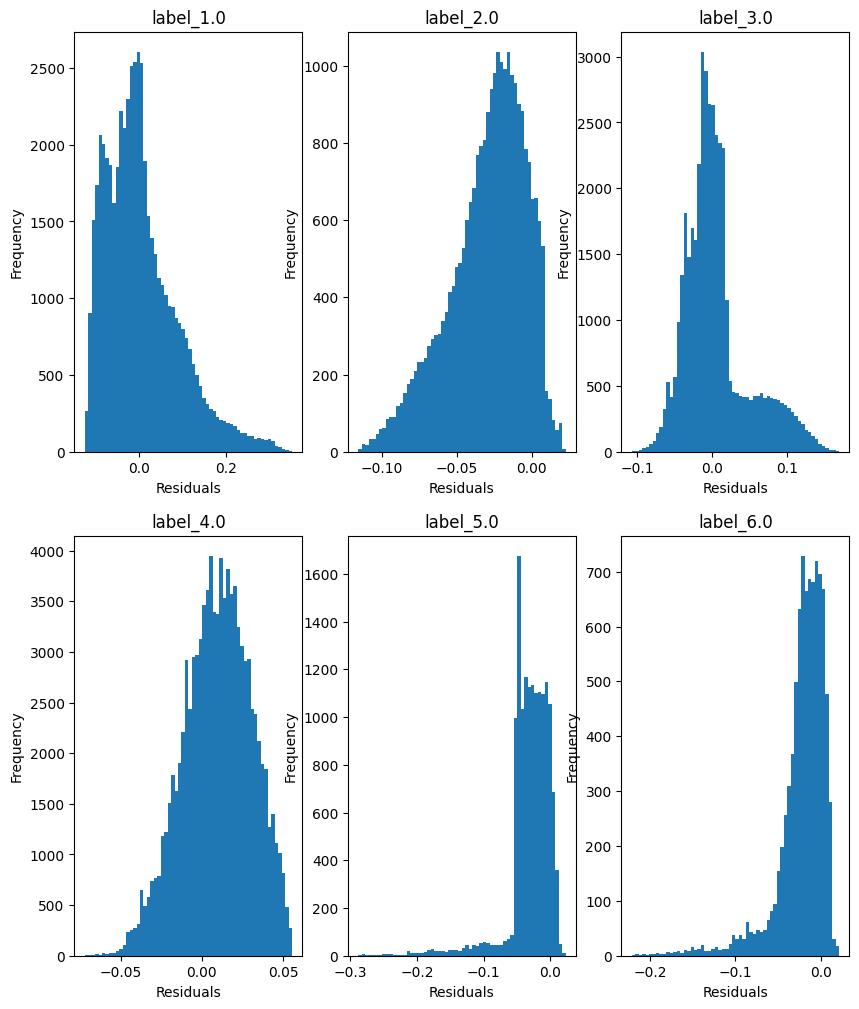

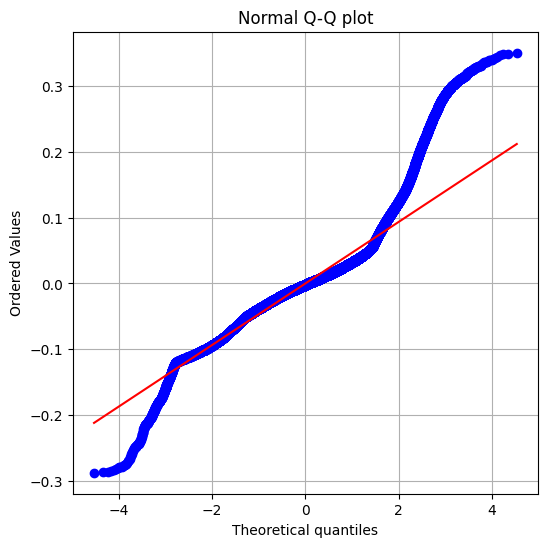

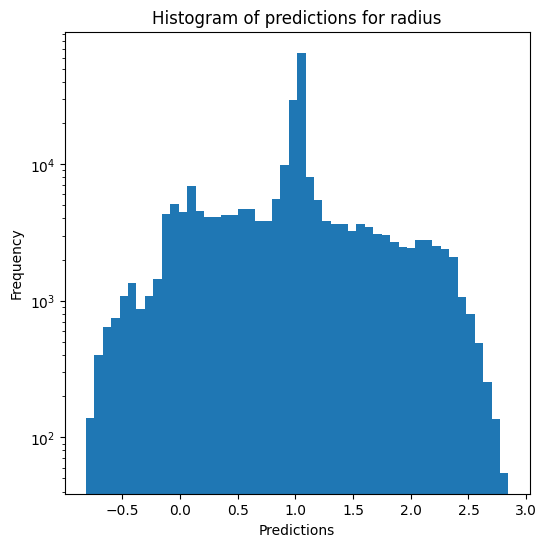

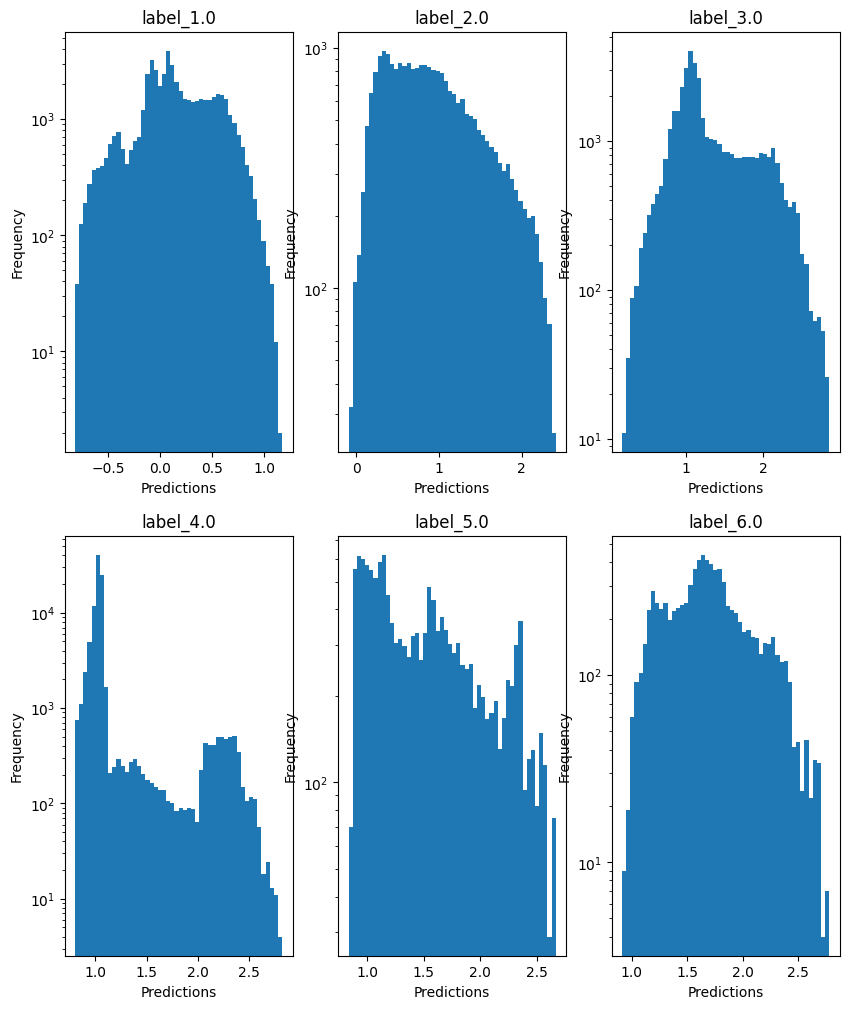

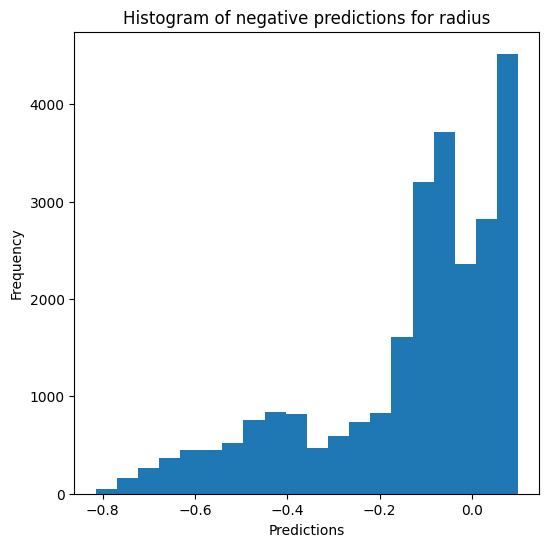

Saving results...


In [10]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) #, override=False, use_preds=True)

### Decision tree

In [11]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9996254161385038
  RMSE :  0.05840340529668738
  MAE :  0.013469273504042142
  MedAE :  0.0
  CORR :  0.9998127048400395
  MAX_ER :  1.633000000000001
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.021999999999999797
    95th percentile :  0.0680000000000005
    99th percentile :  0.2939999999999987

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999459955708547
  RMSE :  0.024641225603144138
  MAE :  0.006320830750155019
  MedAE :  0.0
  CORR :  0.9999730941677303
  MAX_ER :  0.6719999999999988
  Percentiles : 
    75th percentile :  0.0009999999999994458
    90th percentile :  0.016999999999999904
    95th percentile :  0.041999999999999815
    99th percentile :  0.10100000000000081

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.99991573234621

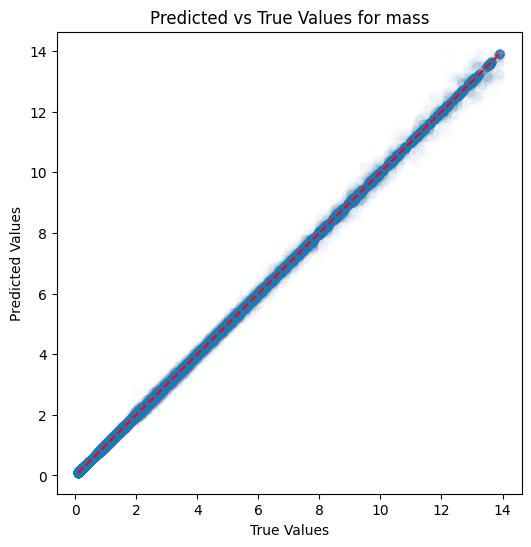

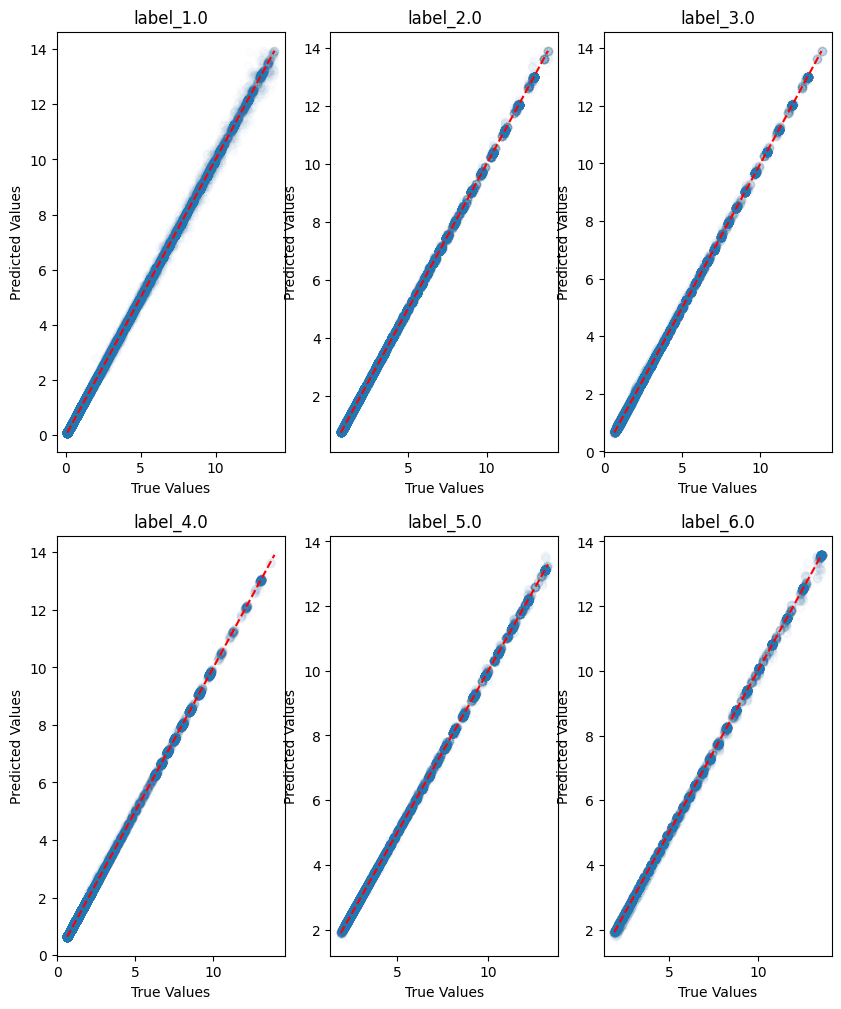

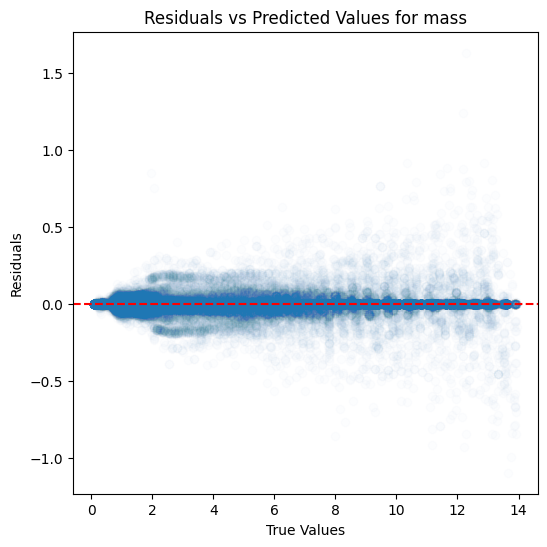

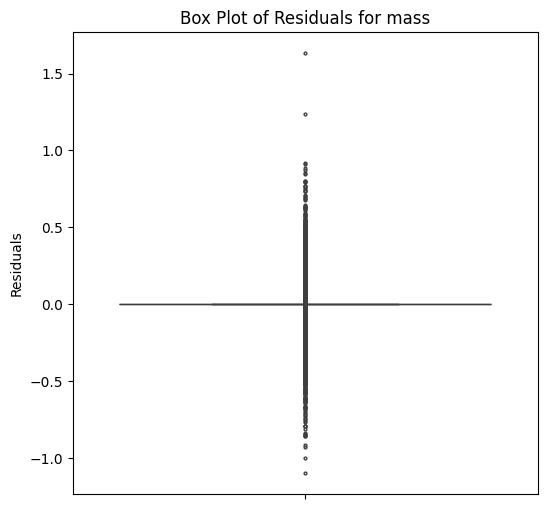

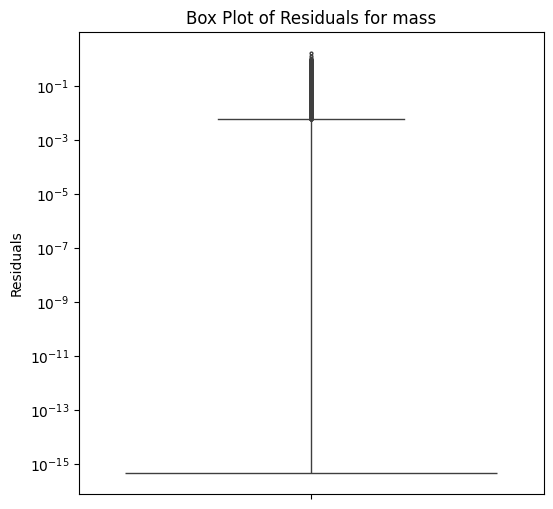

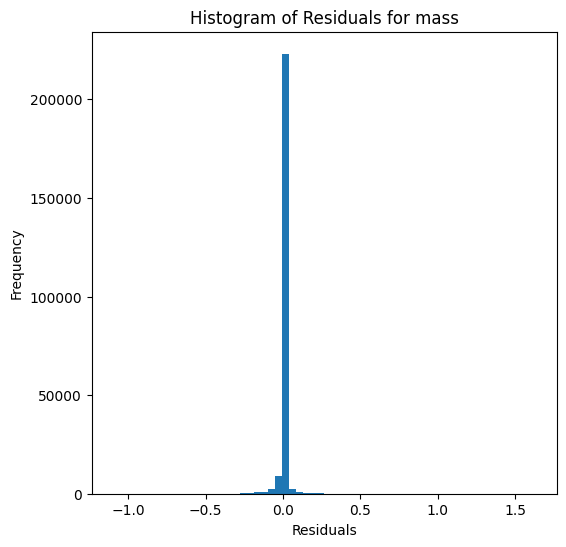

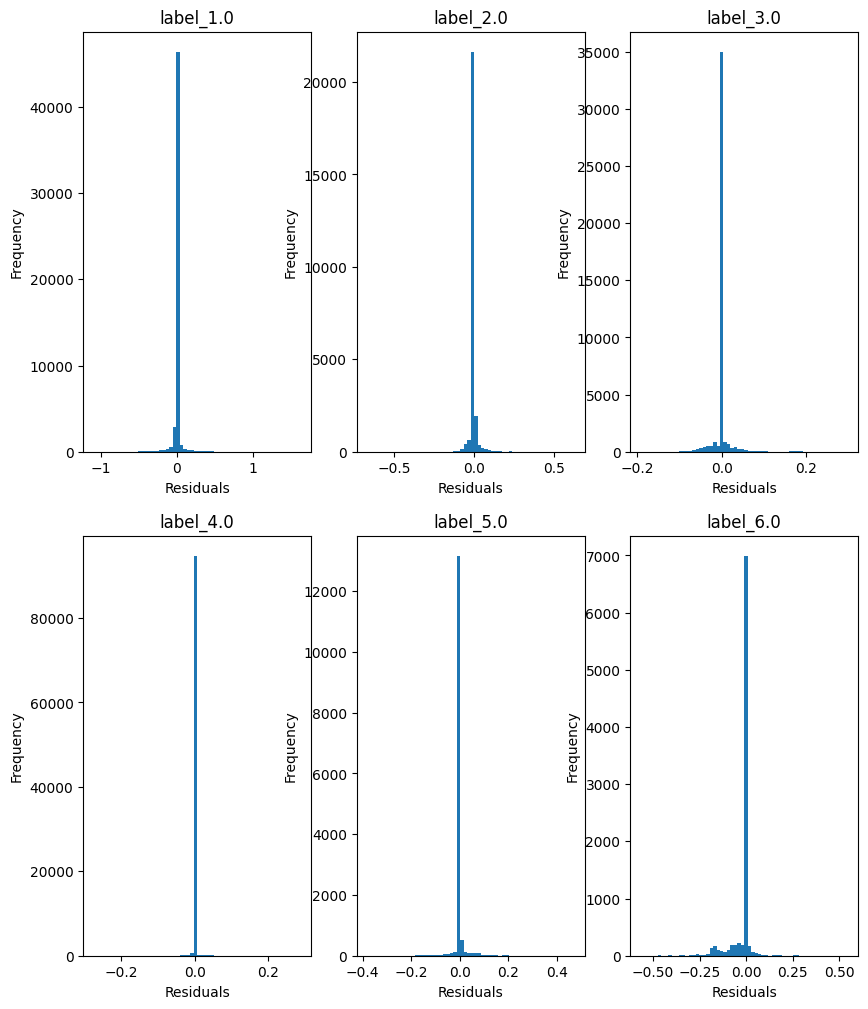

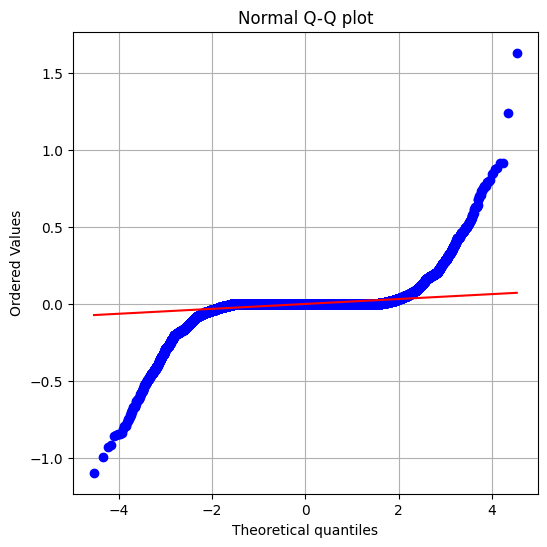

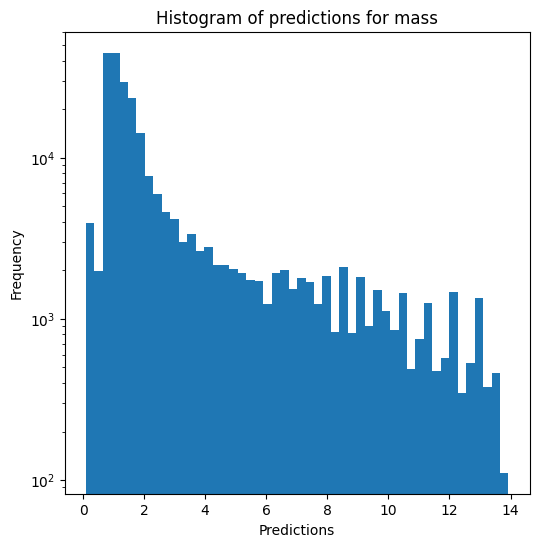

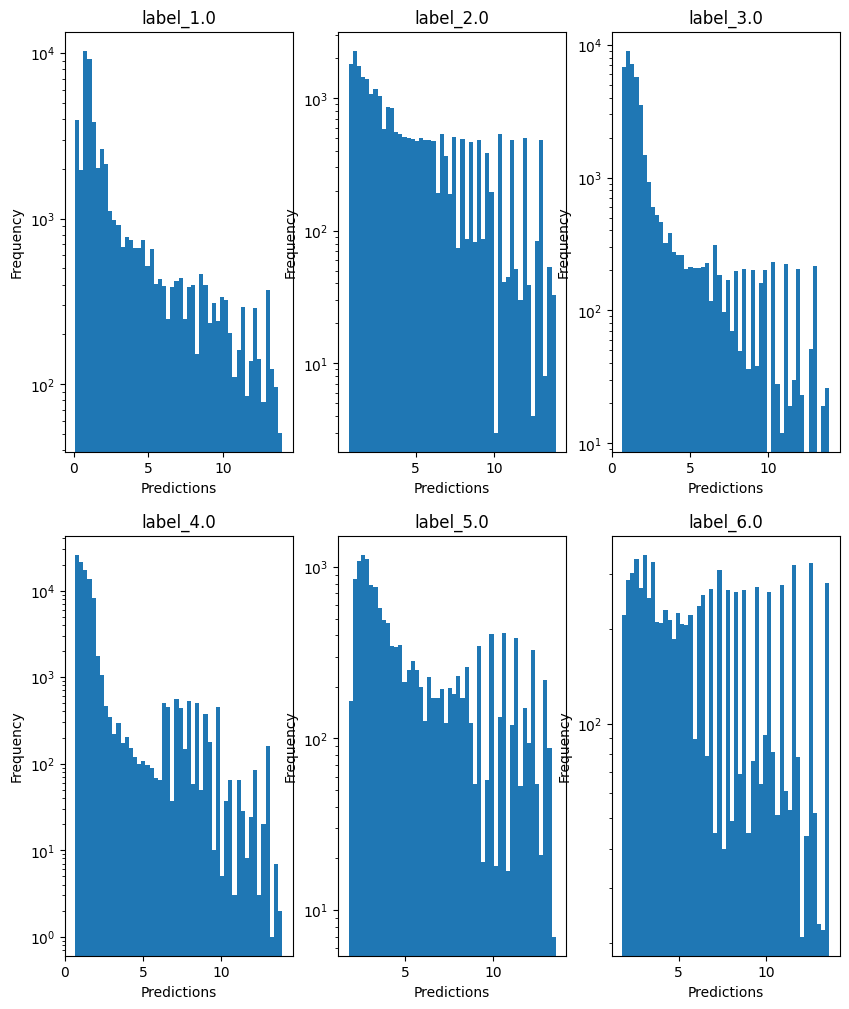

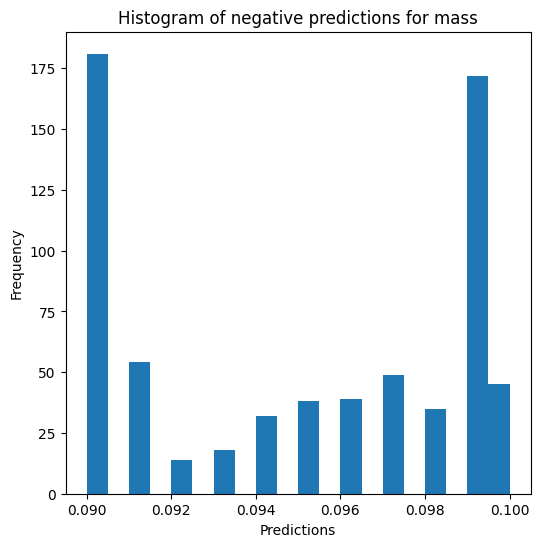

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9996510455556854
  RMSE :  0.00683673795679465
  MAE :  0.0025103299872091785
  MedAE :  2.7755575615628914e-17
  CORR :  0.9998255543922977
  MAX_ER :  0.11918640771920858
  Percentiles : 
    75th percentile :  0.0017268193005059718
    90th percentile :  0.007577893259176086
    95th percentile :  0.013557552743045292
    99th percentile :  0.03205068887084861

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9993088802987002
  RMSE :  0.014231846921850089
  MAE :  0.005530775220687563
  MedAE :  0.0
  CORR :  0.9996583435005846
  MAX_ER :  0.3373776625458338
  Percentiles : 
    75th percentile :  0.006653259164281611
    90th percentile :  0.019387257292060315
    95th percentile :  0.025521814873945694
    99th percentile :  0.047318414955507745

radius results for the label cate

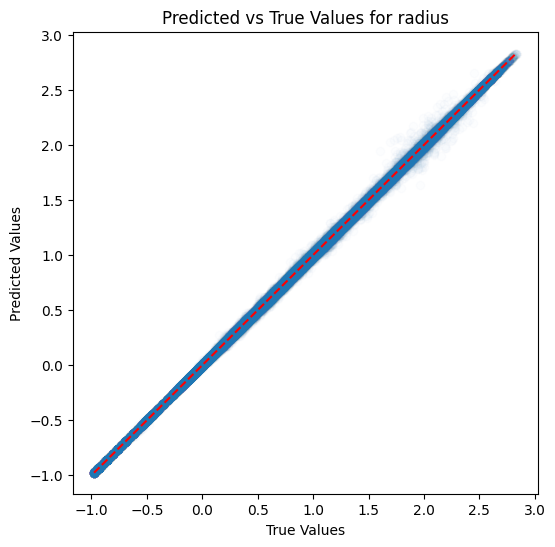

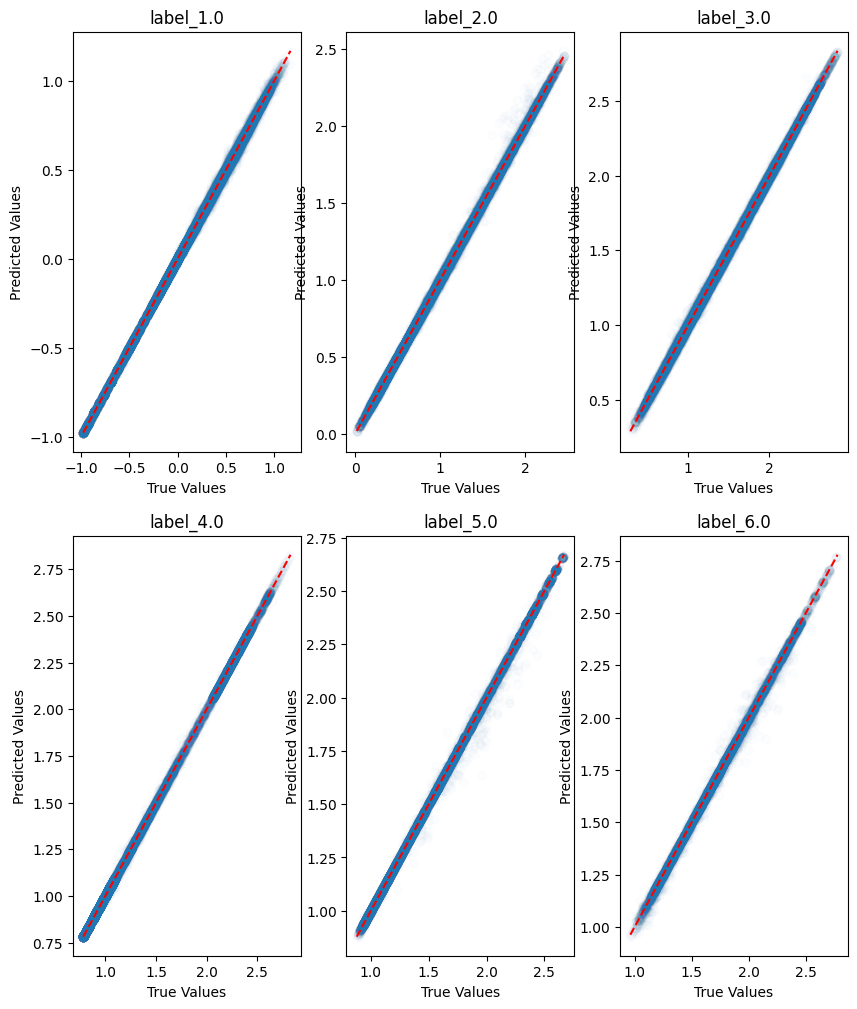

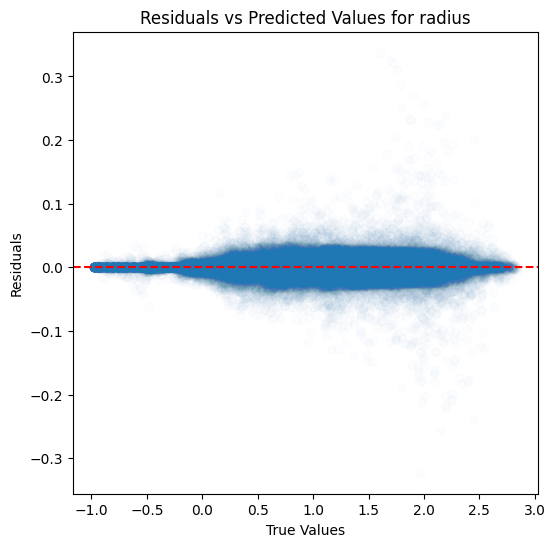

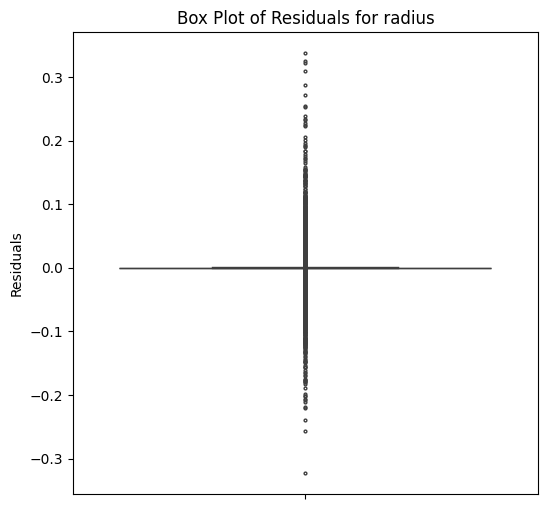

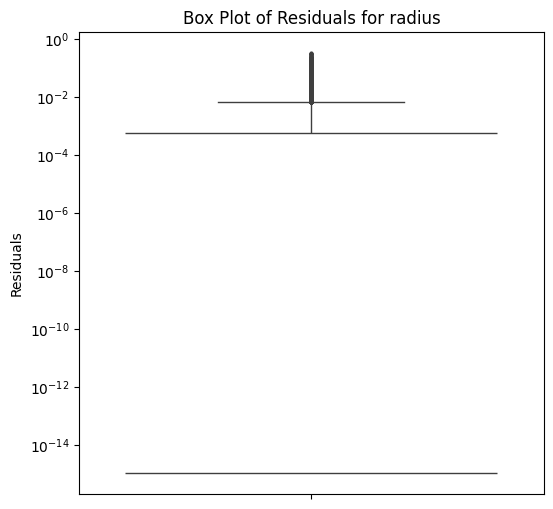

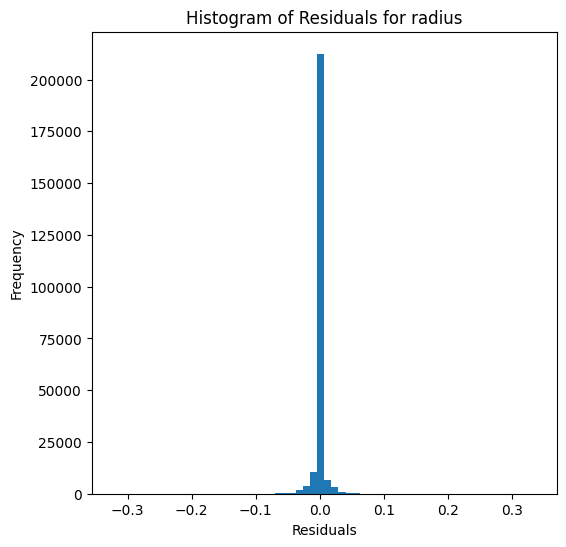

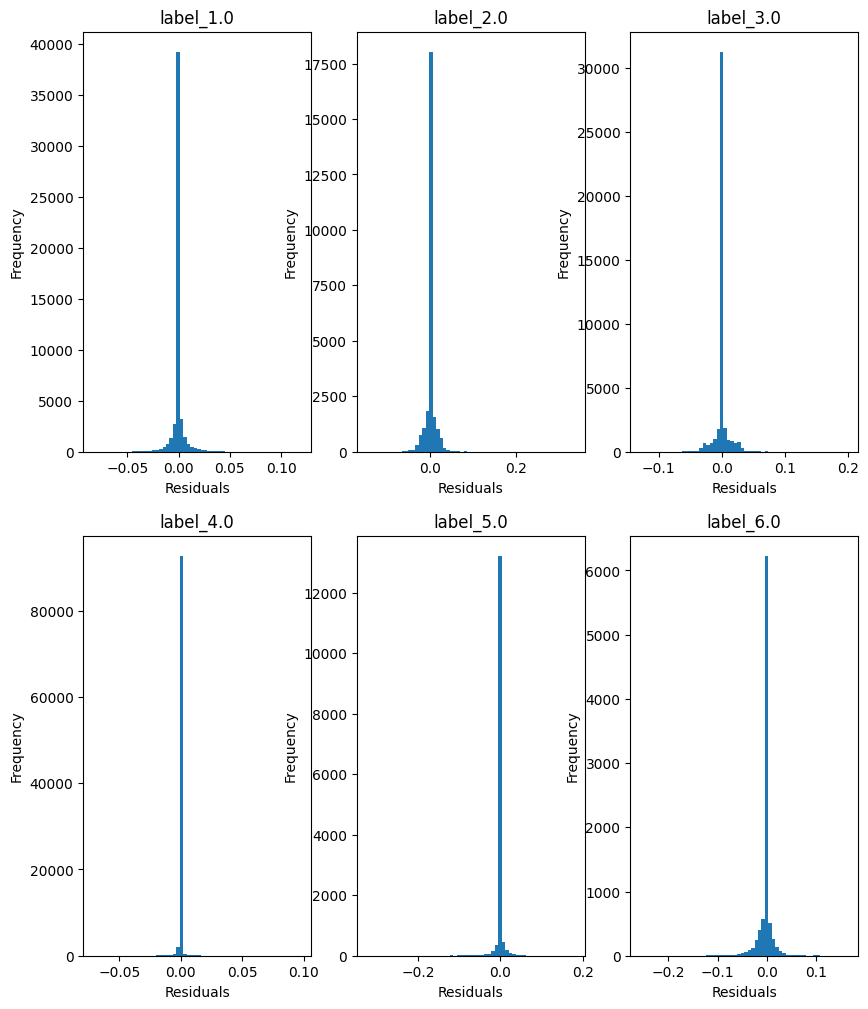

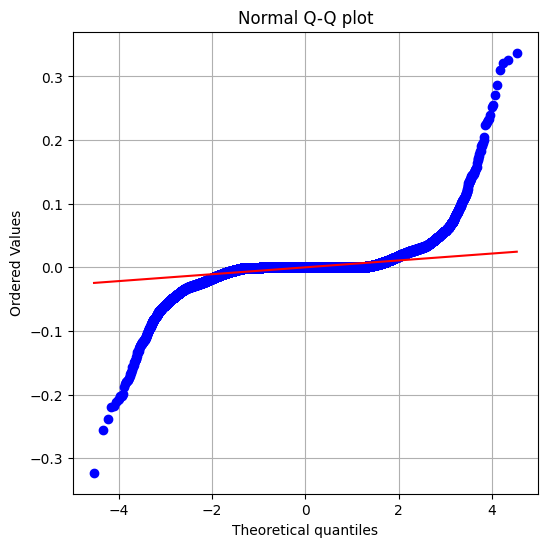

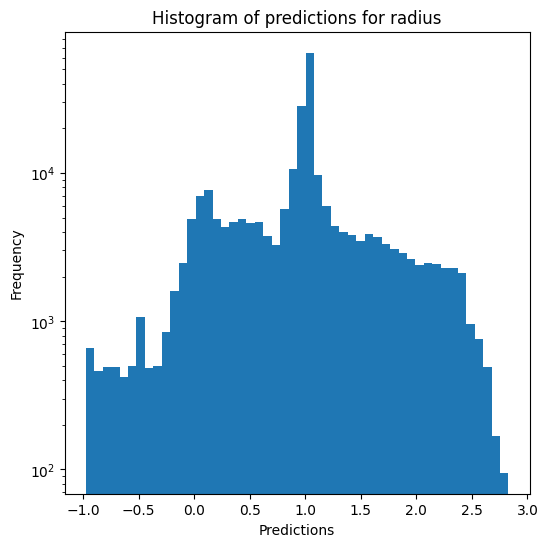

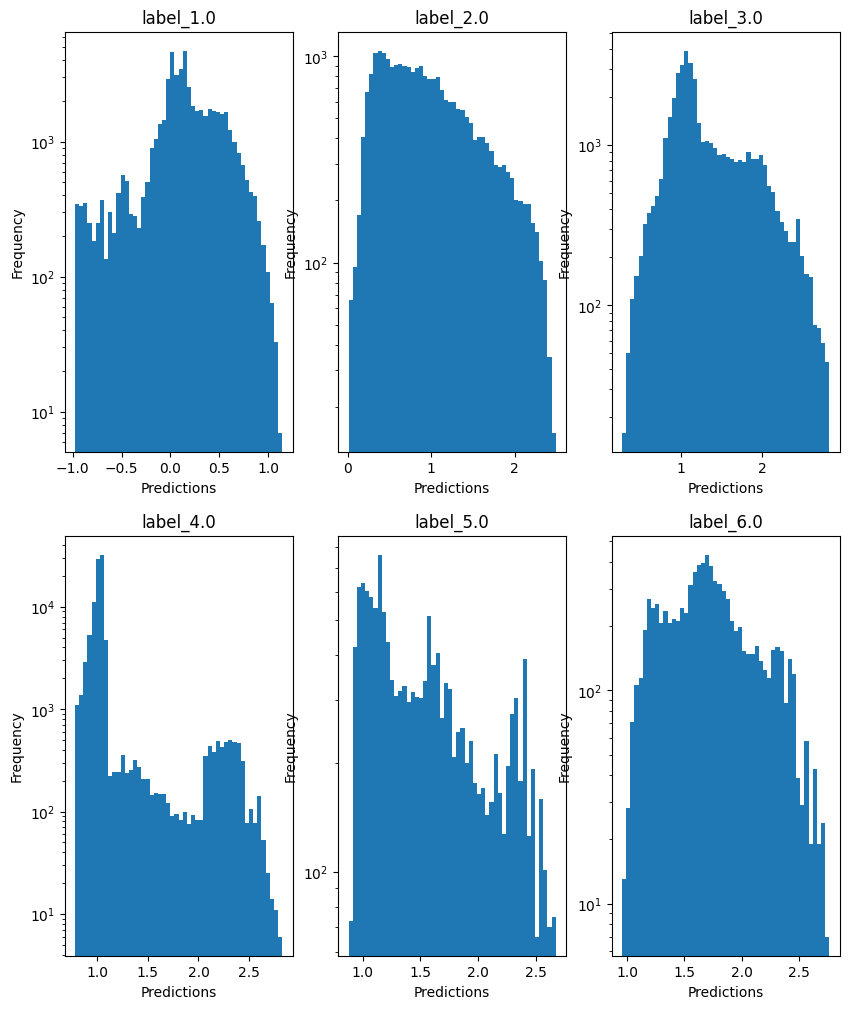

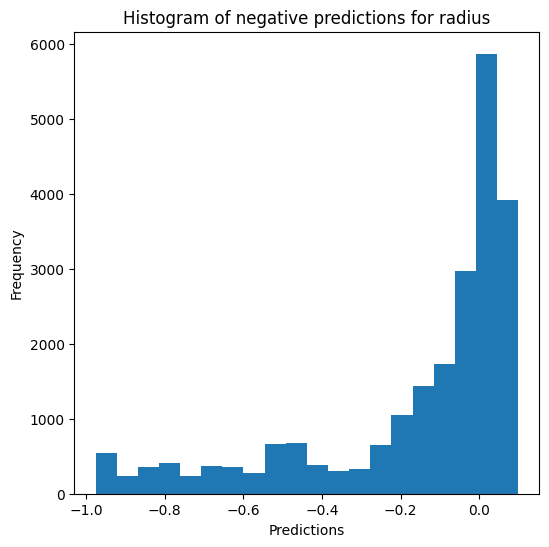

Saving results...


In [12]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) #, override=False, use_preds=True)

### K-nearest neighbours

In [13]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9970182995079786
  RMSE :  0.1647753704342362
  MAE :  0.056744259561081006
  MedAE :  0.01100000000000012
  CORR :  0.9985271249816617
  MAX_ER :  5.044599999999999
  Percentiles : 
    75th percentile :  0.043599999999999944
    90th percentile :  0.14080000000000115
    95th percentile :  0.264349999999999
    99th percentile :  0.7288000000000003

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9986590142761502
  RMSE :  0.12286979026424039
  MAE :  0.05731495660260385
  MedAE :  0.018999999999999906
  CORR :  0.9993351850480691
  MAX_ER :  1.3902
  Percentiles : 
    75th percentile :  0.0627999999999993
    90th percentile :  0.14326000000000028
    95th percentile :  0.24145999999999826
    99th percentile :  0.5687300000000015

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.99951

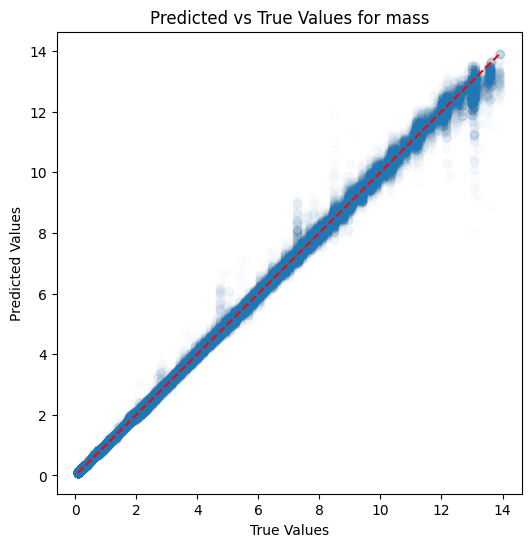

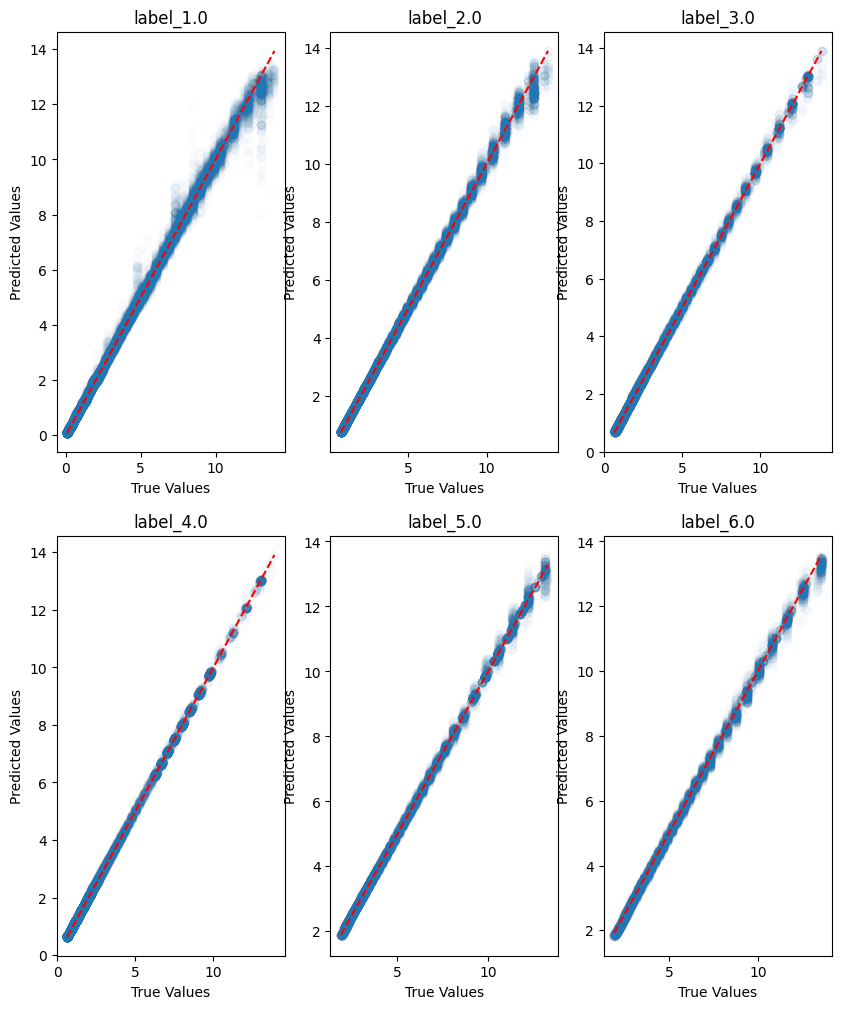

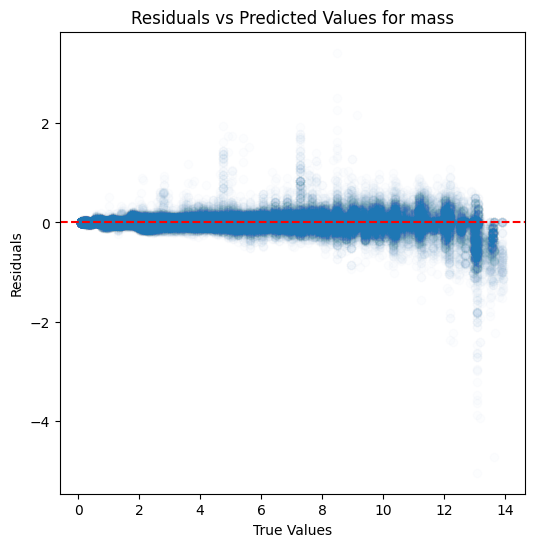

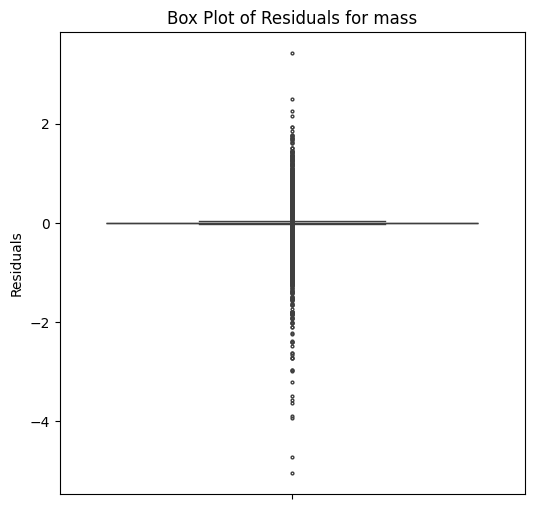

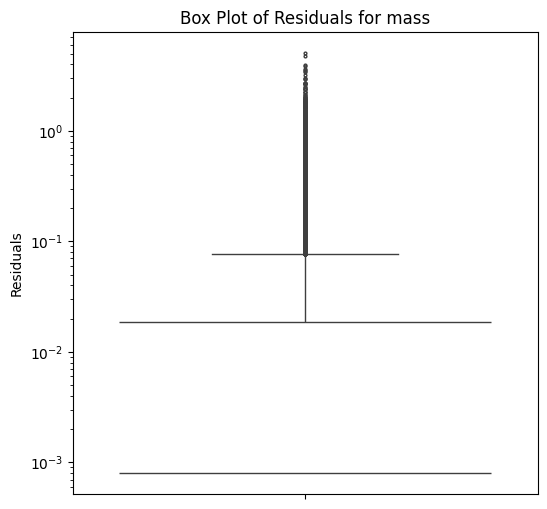

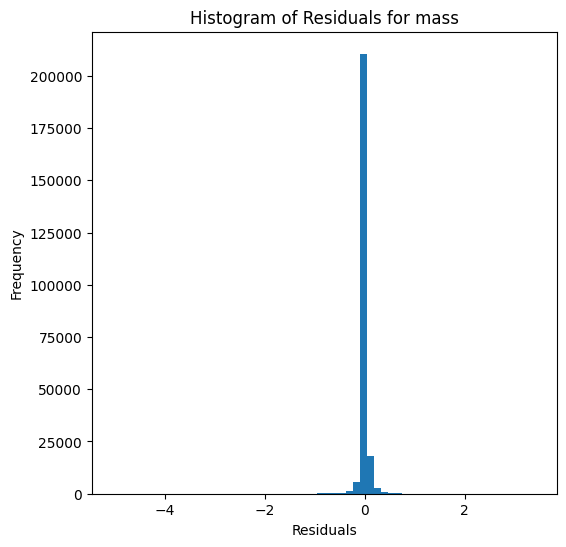

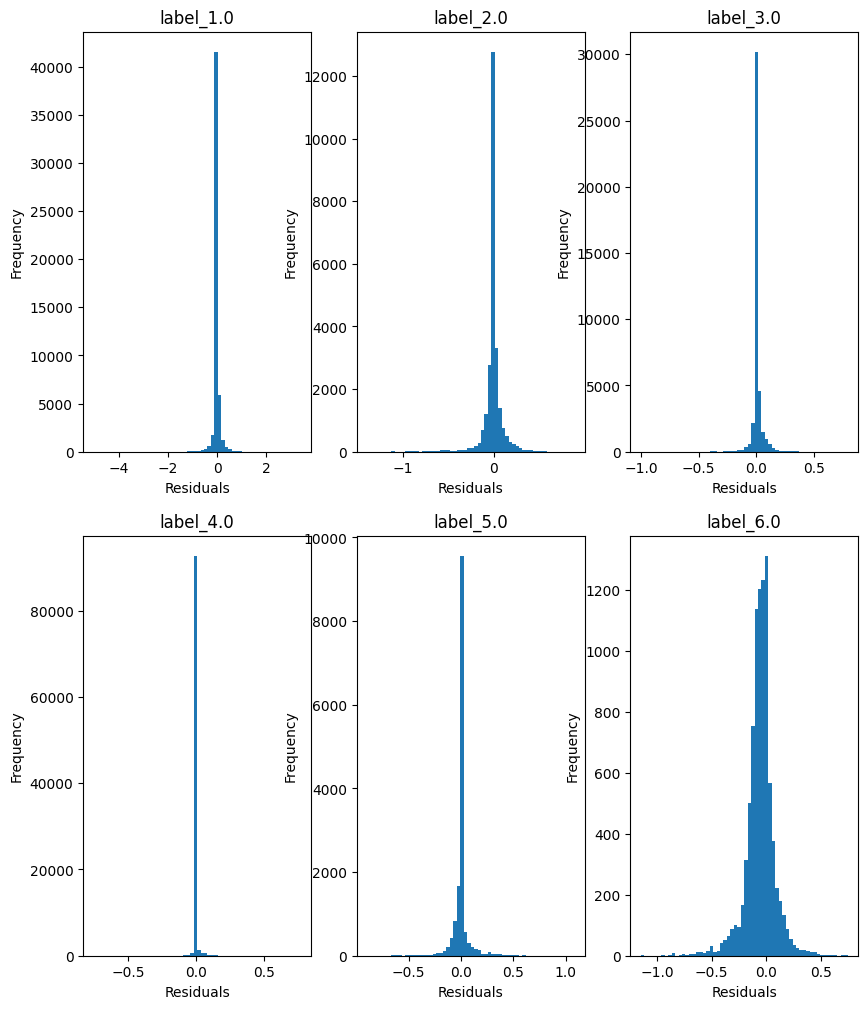

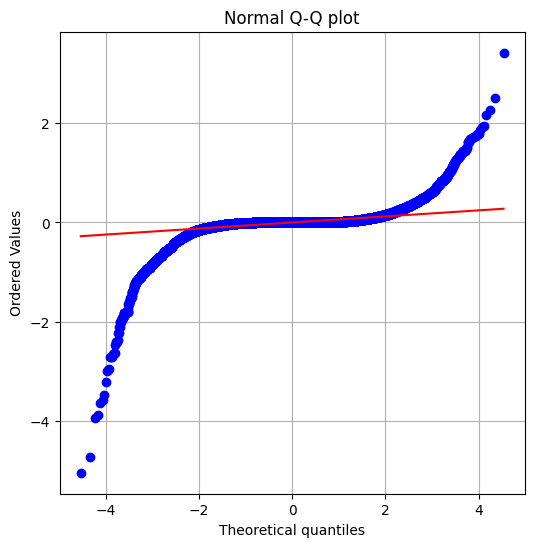

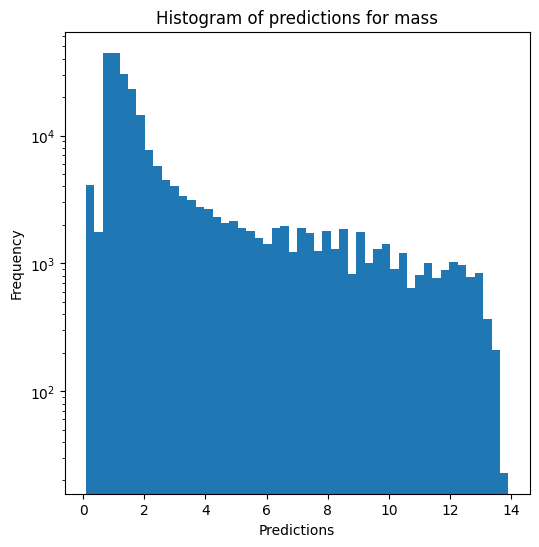

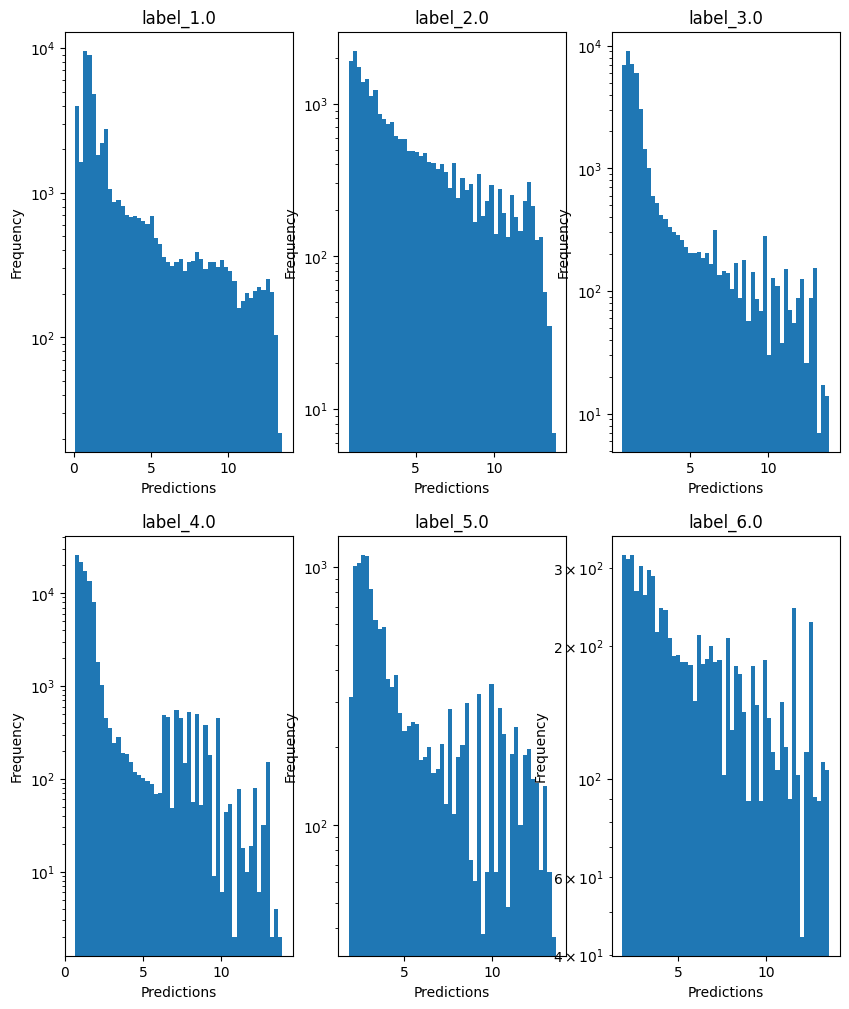

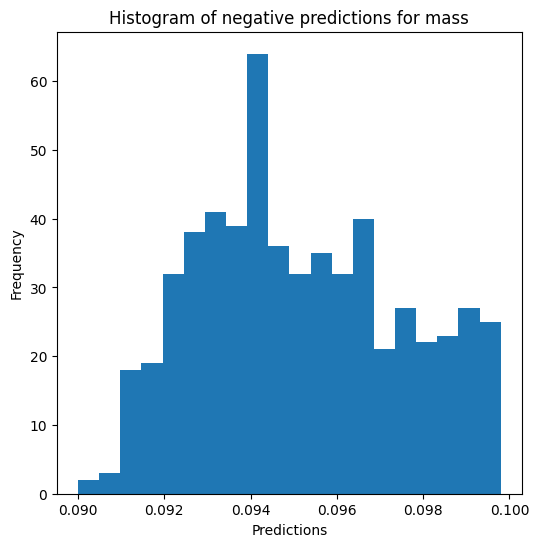


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.999189817501549
  RMSE :  0.010435504649753138
  MAE :  0.006517645170920483
  MedAE :  0.004030783090865381
  CORR :  0.9995968900343201
  MAX_ER :  0.136908653528043
  Percentiles : 
    75th percentile :  0.009110137380981681
    90th percentile :  0.015619846115249442
    95th percentile :  0.020977071423800012
    99th percentile :  0.03850847326019834

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9995060177289445
  RMSE :  0.012076502958738434
  MAE :  0.006557152898135641
  MedAE :  0.004361558569092205
  CORR :  0.9997680701615442
  MAX_ER :  0.28715046126687094
  Percentiles : 
    75th percentile :  0.00804788401706219
    90th percentile :  0.01282479668707008
    95th percentile :  0.01738101834666464
    99th percentile :  0.041063309296671936

radius results for the l

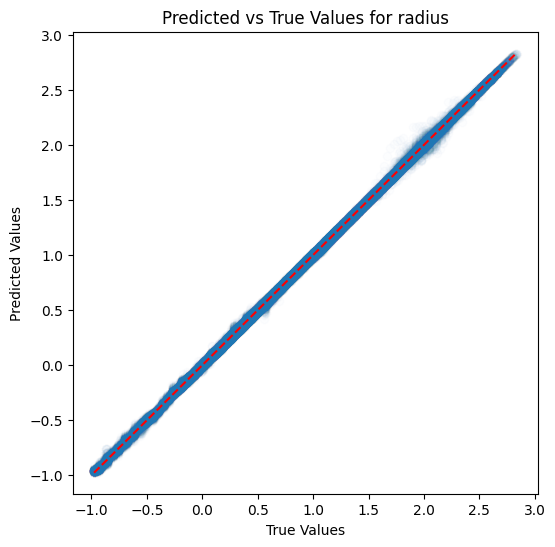

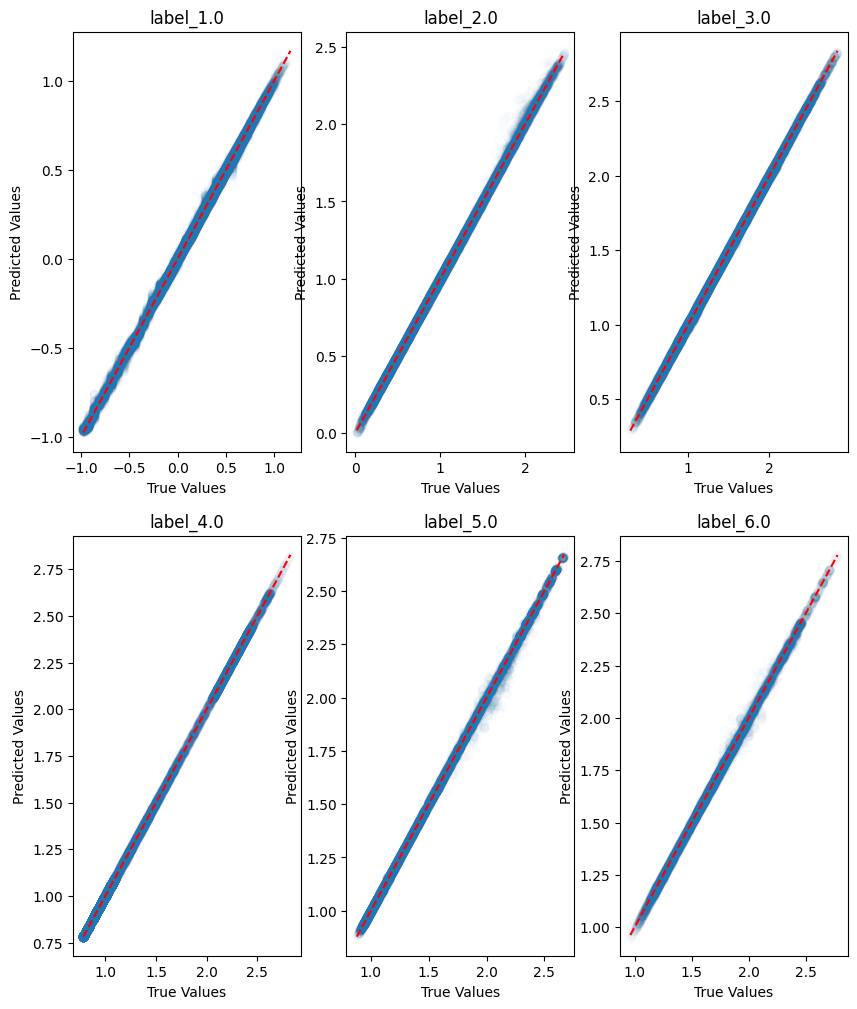

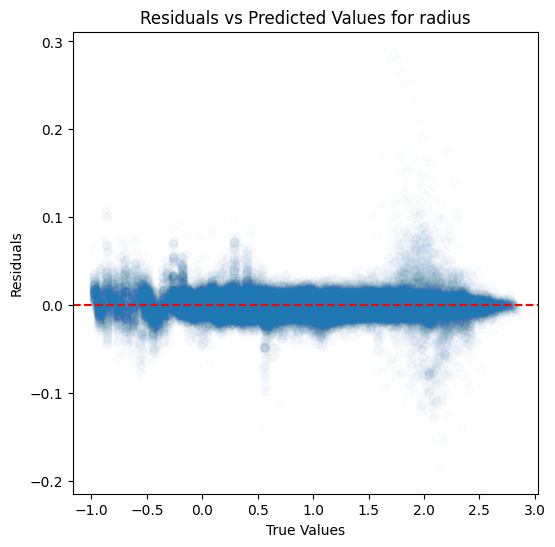

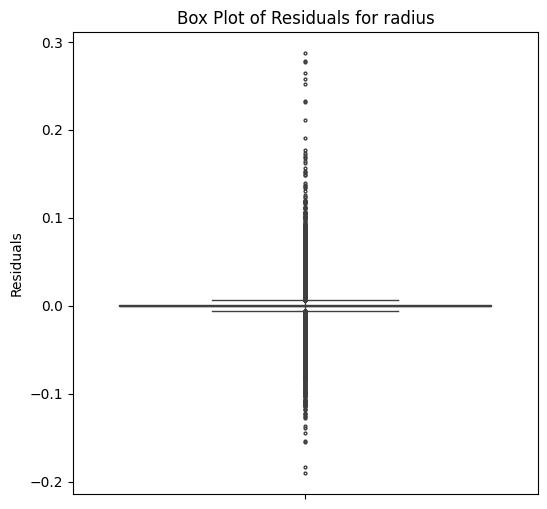

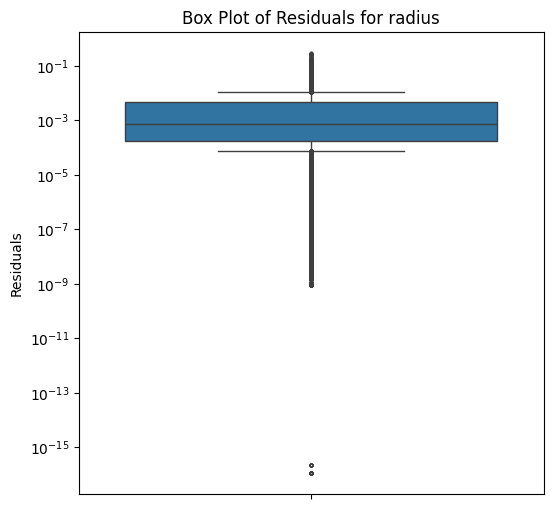

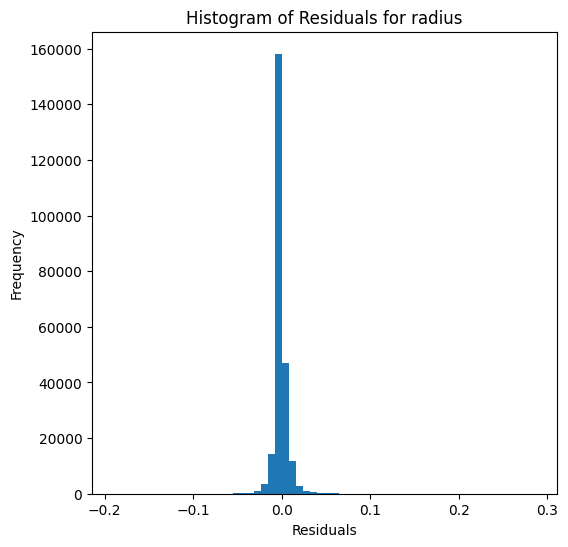

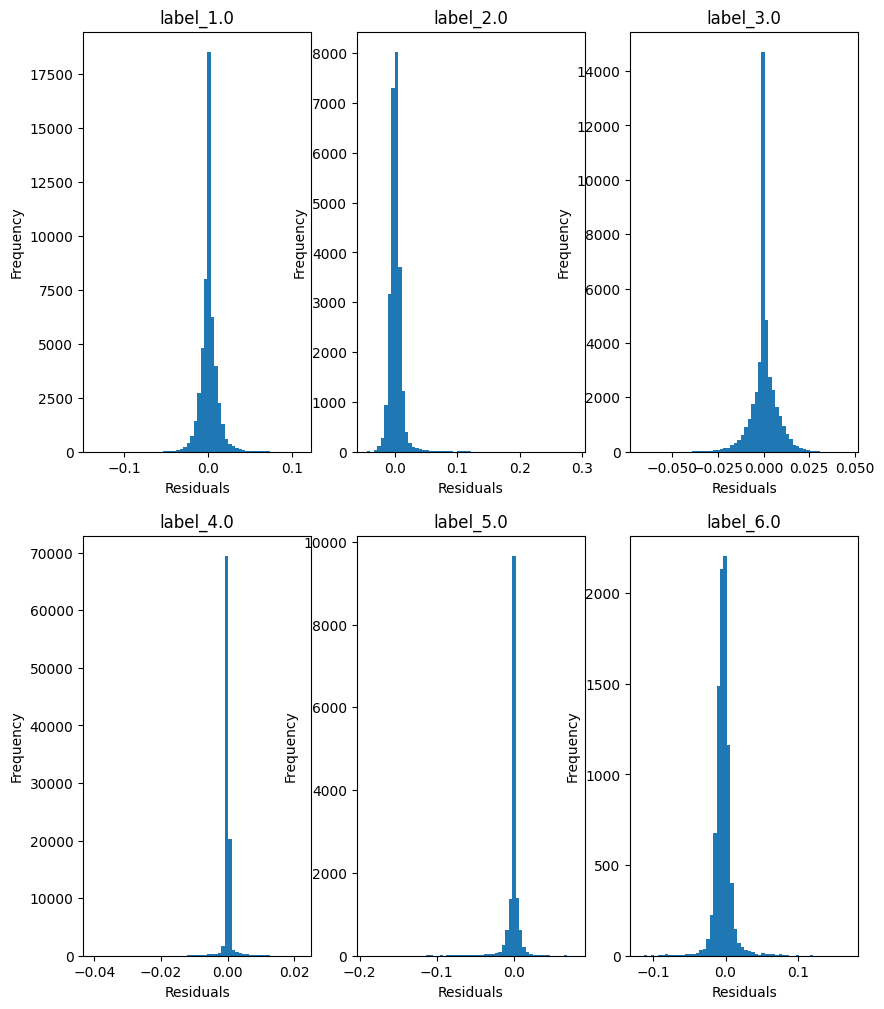

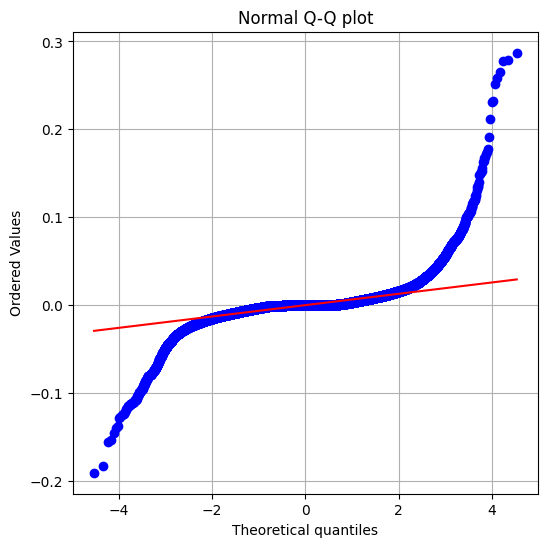

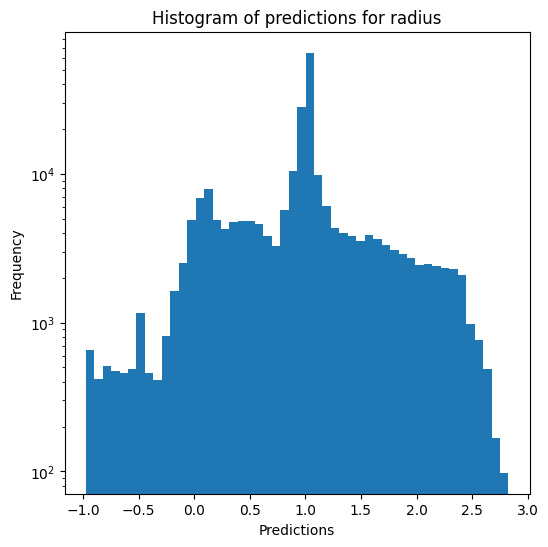

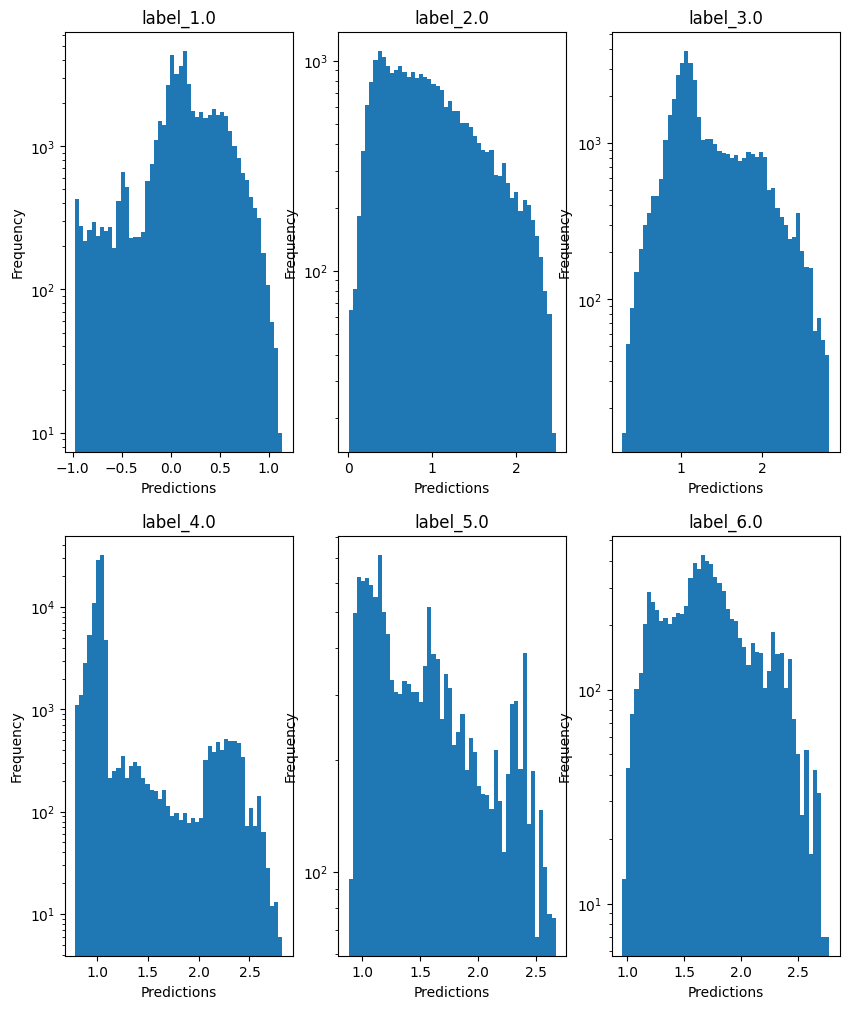

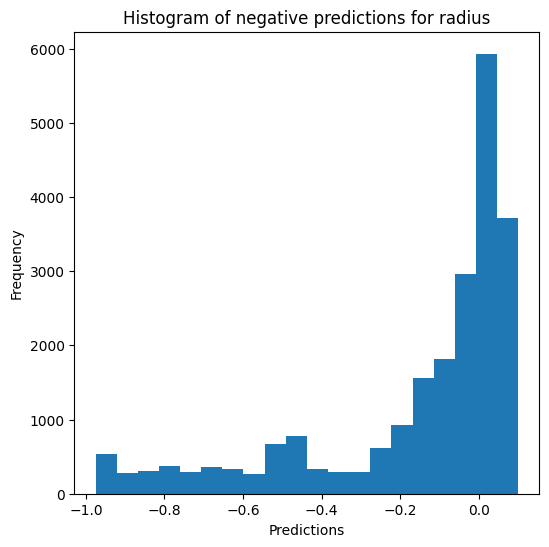

Saving results...


In [14]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [15]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998845663220531
  RMSE :  0.03242170732272036
  MAE :  0.008655048540270082
  MedAE :  0.0002600000000016478
  CORR :  0.9999423032749245
  MAX_ER :  0.7621299999999884
  Percentiles : 
    75th percentile :  0.0033500000000024066
    90th percentile :  0.019075000000003728
    95th percentile :  0.043980000000003794
    99th percentile :  0.1491499999999986

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999713505655556
  RMSE :  0.01795925059369213
  MAE :  0.0069542368802229665
  MedAE :  0.0005800000000046879
  CORR :  0.9999857375598071
  MAX_ER :  0.5654600000000052
  Percentiles : 
    75th percentile :  0.006702500000002498
    90th percentile :  0.021555999999997452
    95th percentile :  0.03399999999999861
    99th percentile :  0.06873929999999728

mass results for the label cate

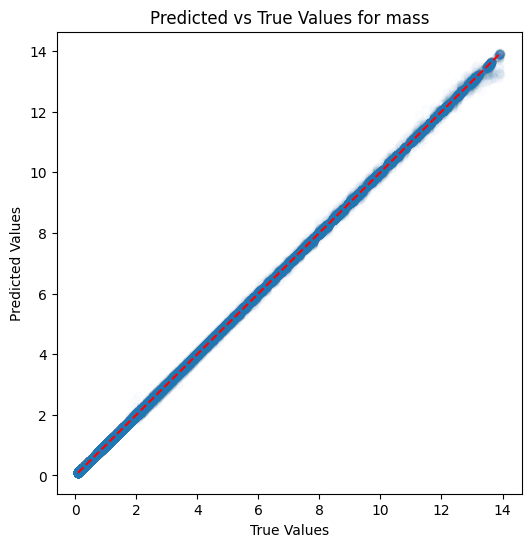

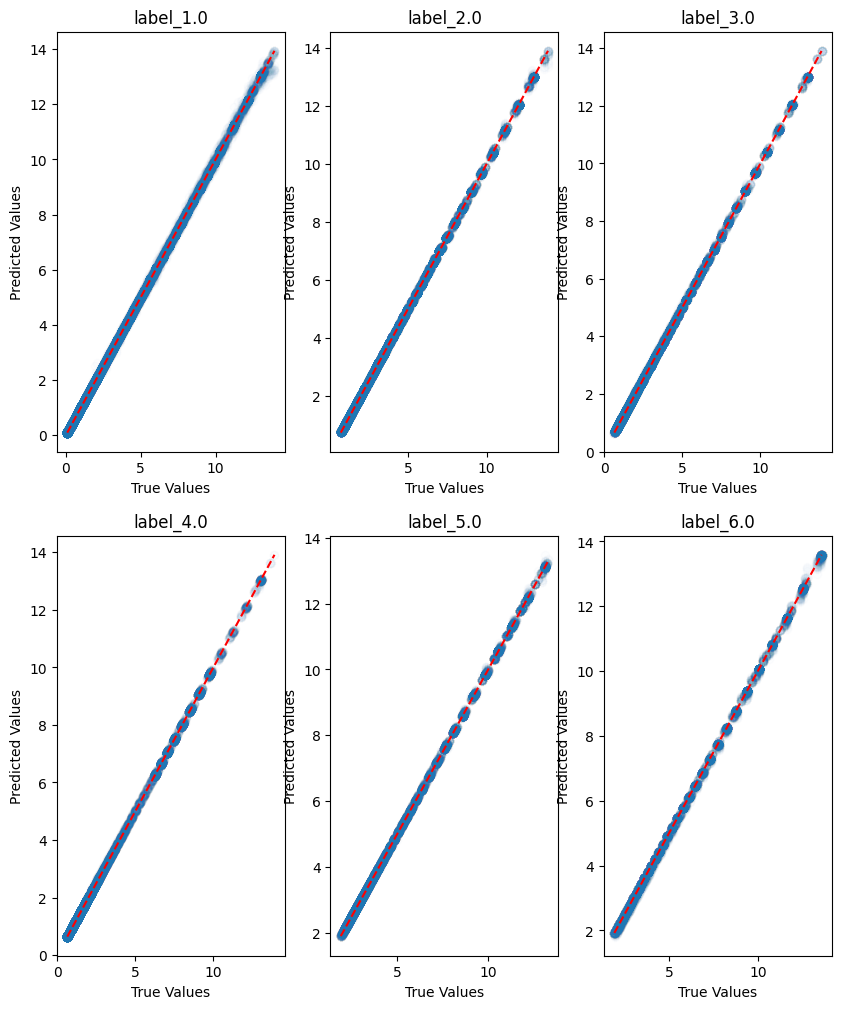

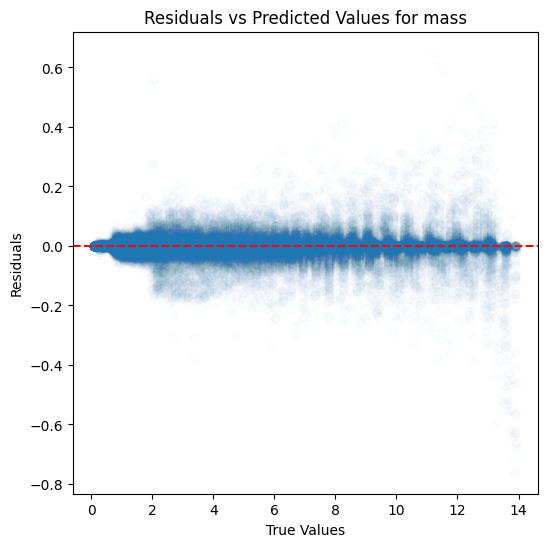

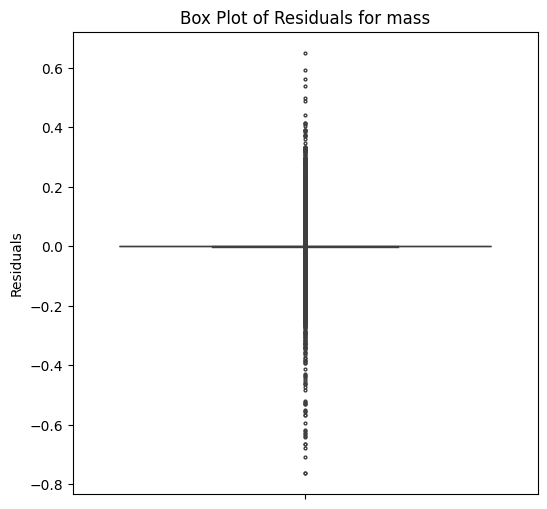

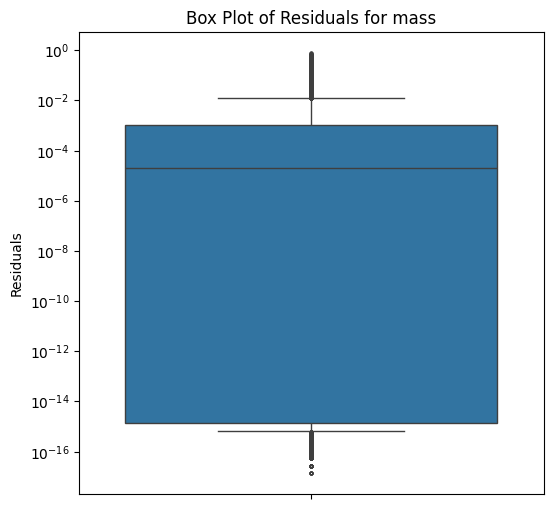

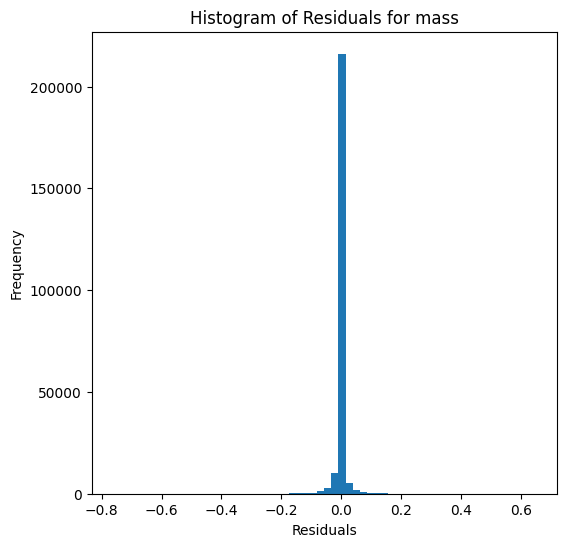

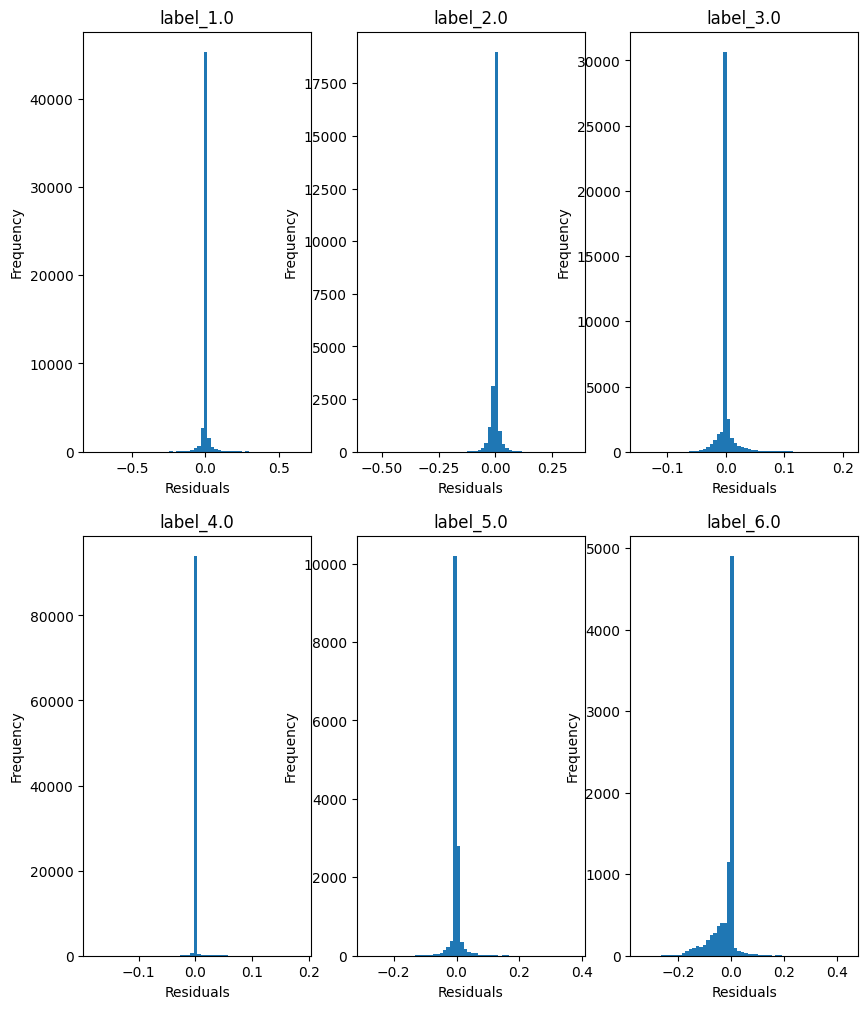

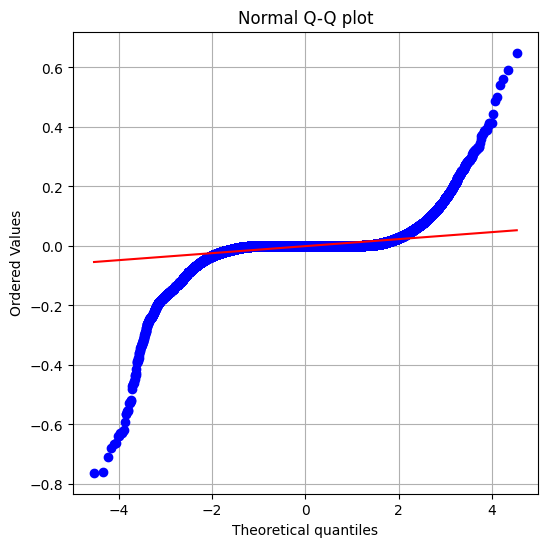

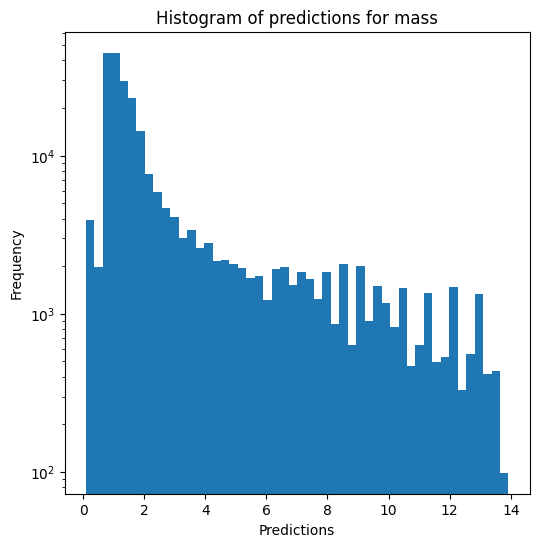

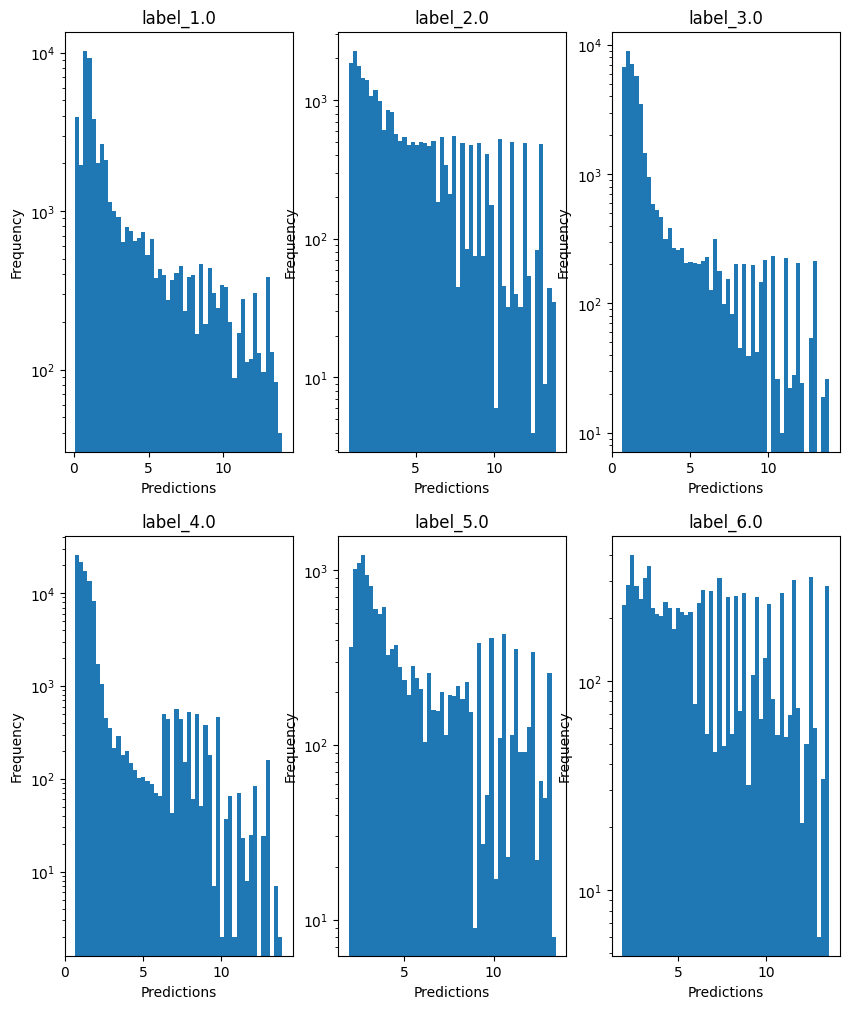

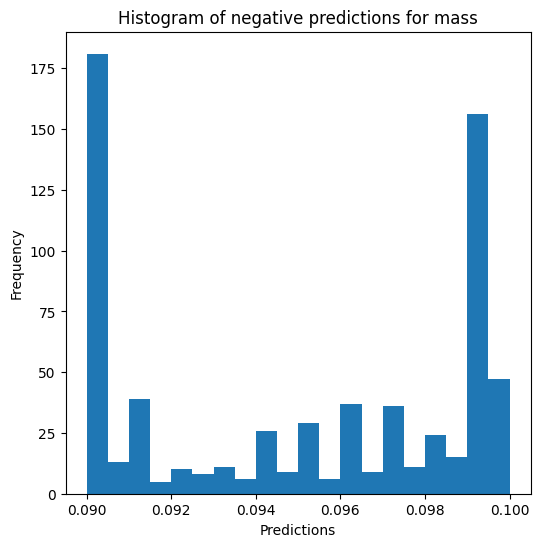


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9999197322025316
  RMSE :  0.0032788552210763896
  MAE :  0.0013057244322726821
  MedAE :  0.00018112114567073873
  CORR :  0.9999599357955143
  MAX_ER :  0.0707659859859224
  Percentiles : 
    75th percentile :  0.0010757963410600868
    90th percentile :  0.0038957664549496285
    95th percentile :  0.006757793196262546
    99th percentile :  0.014452099960377789

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9997670556315849
  RMSE :  0.008291207279458169
  MAE :  0.00282362516989707
  MedAE :  0.00044907592050269507
  CORR :  0.9998880153089946
  MAX_ER :  0.2633429653822823
  Percentiles : 
    75th percentile :  0.0027178283178230234
    90th percentile :  0.007718435313257598
    95th percentile :  0.012042526174983142
    99th percentile :  0.029042465925835252

radius resu

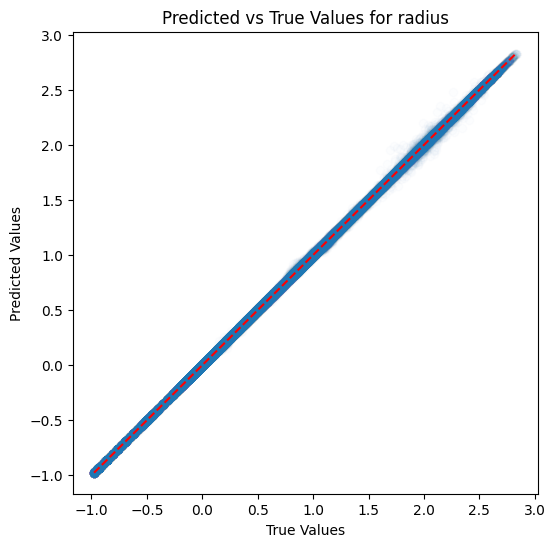

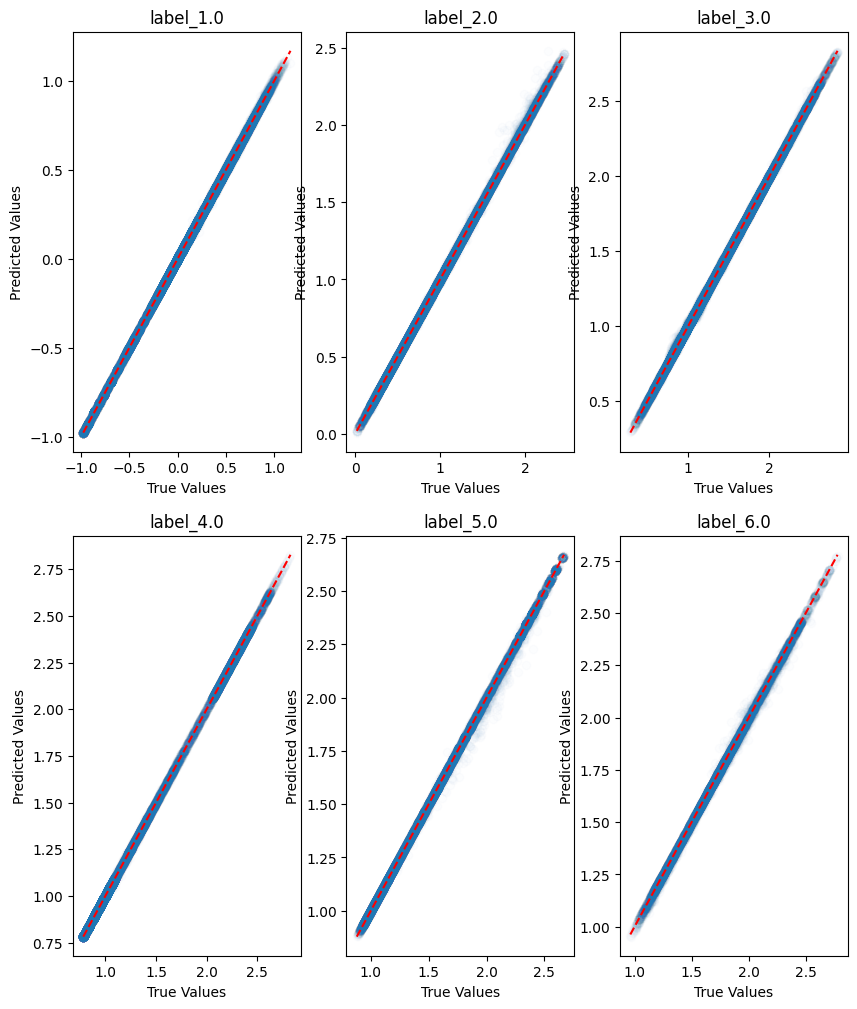

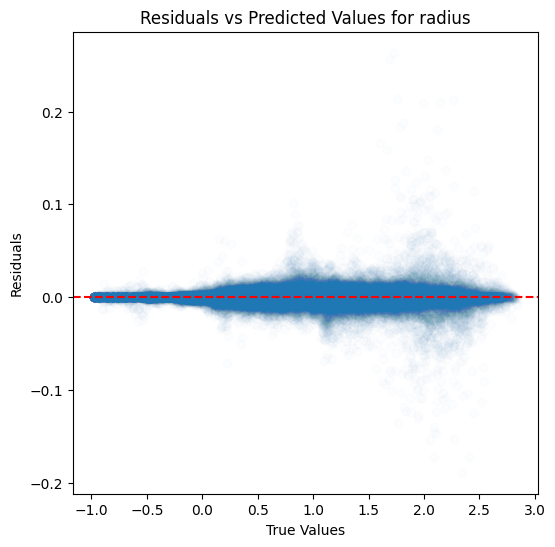

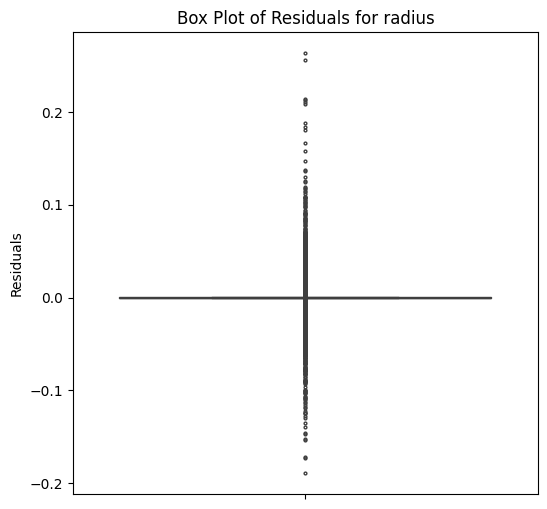

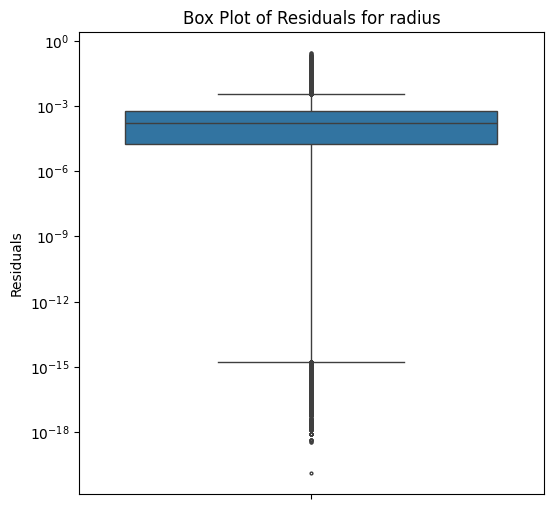

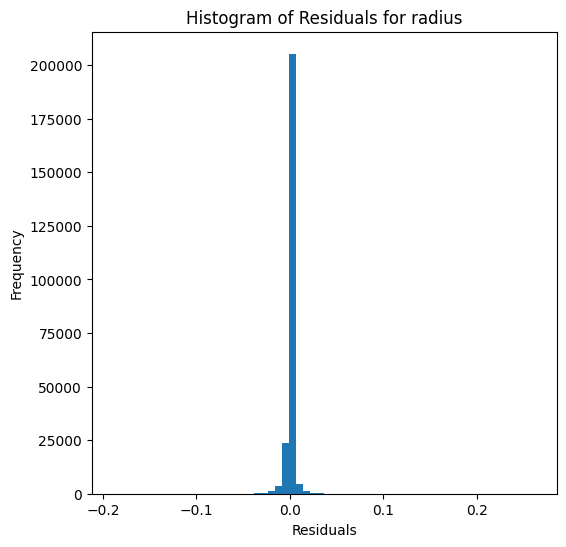

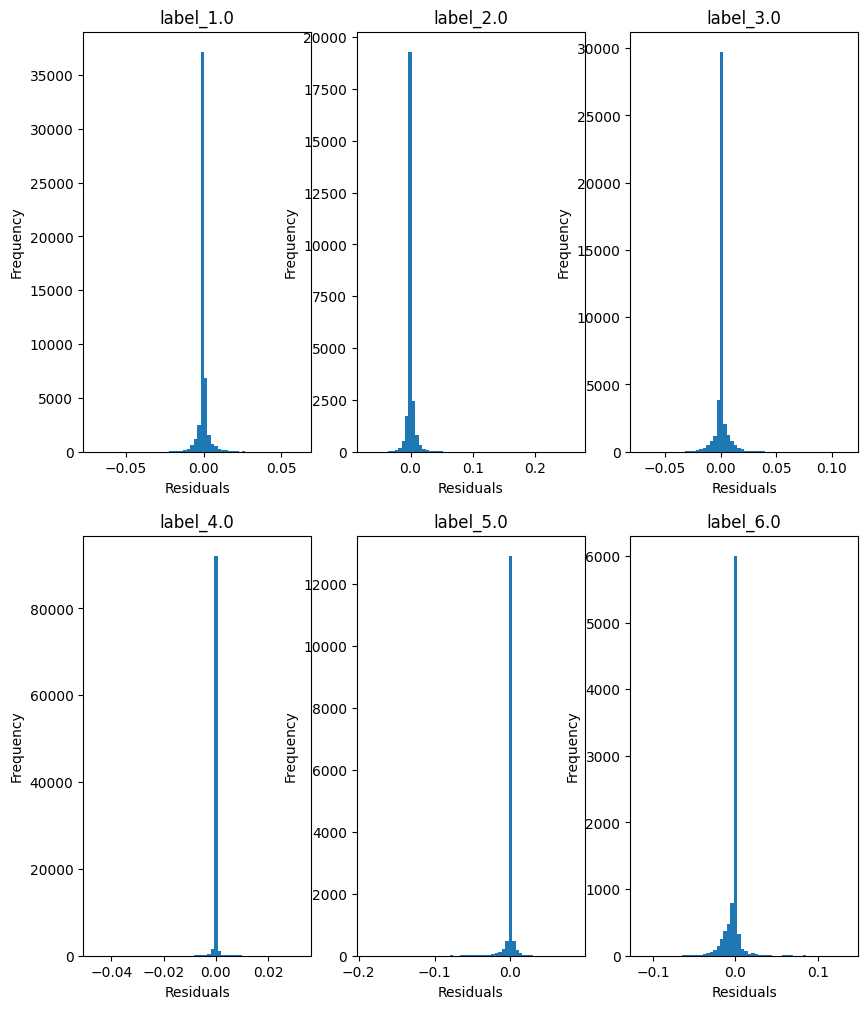

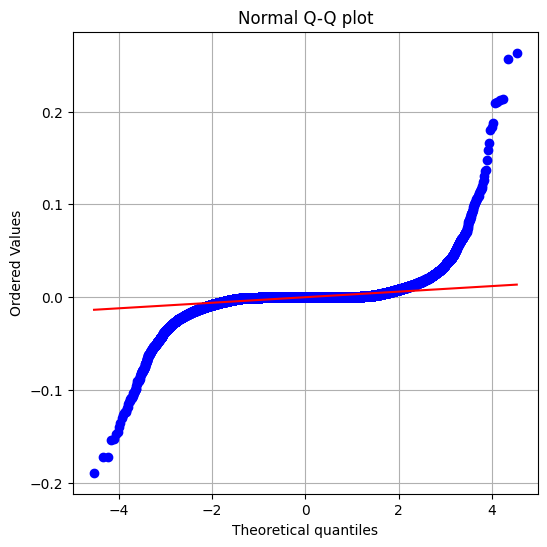

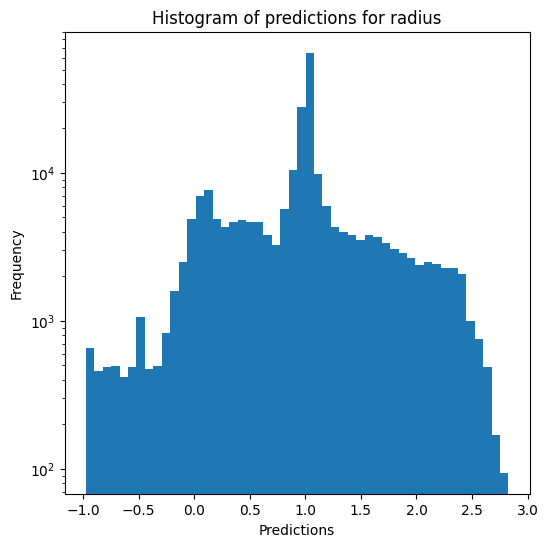

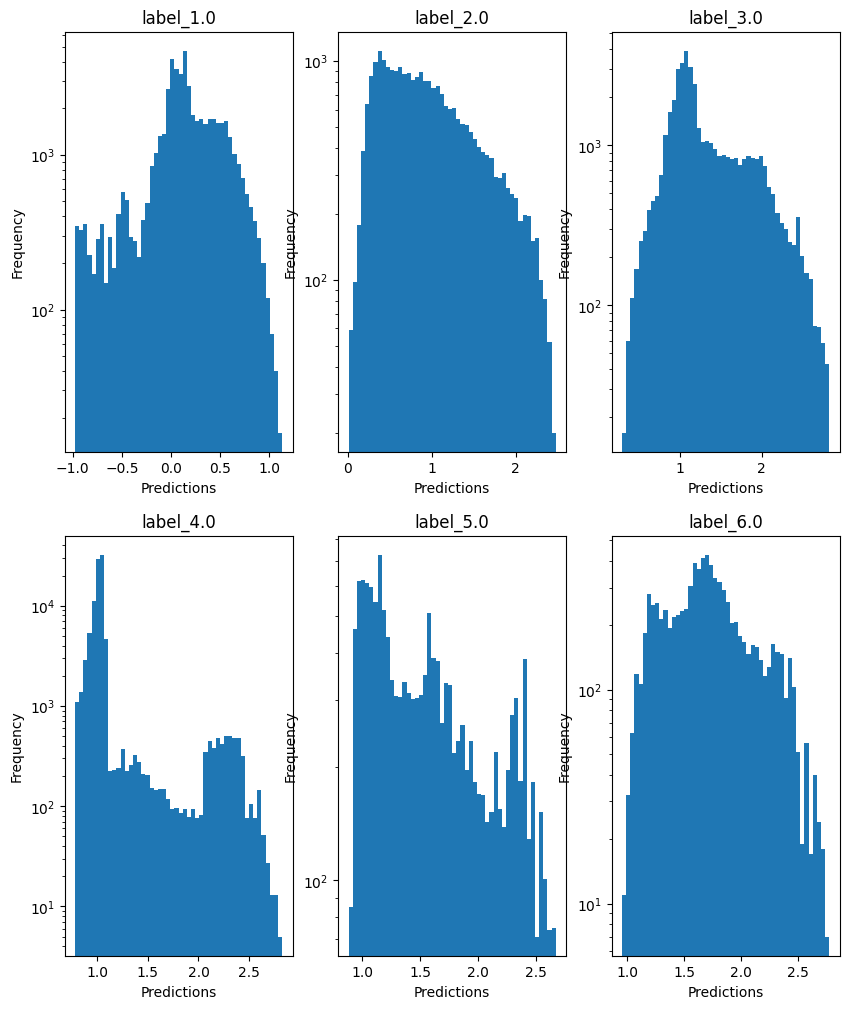

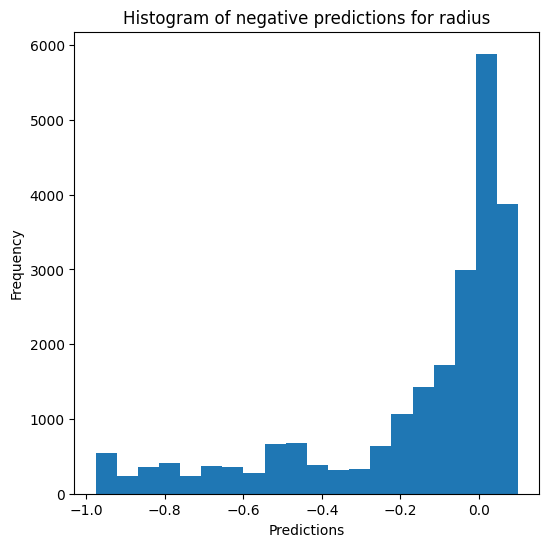

Saving results...


In [16]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### XGBoost

In [17]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991350851722829
  RMSE :  0.0887554156625211
  MAE :  0.046886387633201056
  MedAE :  0.020626248836517425
  CORR :  0.999567813034968
  MAX_ER :  1.4695928878784184
  Percentiles : 
    75th percentile :  0.05201218032836952
    90th percentile :  0.11996983242034909
    95th percentile :  0.18982356643676757
    99th percentile :  0.37039495620727525

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999888070822217
  RMSE :  0.03612342170599431
  MAE :  0.02399718580019451
  MedAE :  0.01514275693893452
  CORR :  0.9999466740441237
  MAX_ER :  0.3200783462524406
  Percentiles : 
    75th percentile :  0.031249127388000564
    90th percentile :  0.05624012413024876
    95th percentile :  0.07732287445068352
    99th percentile :  0.12993653633117735

mass results for the label category with a 

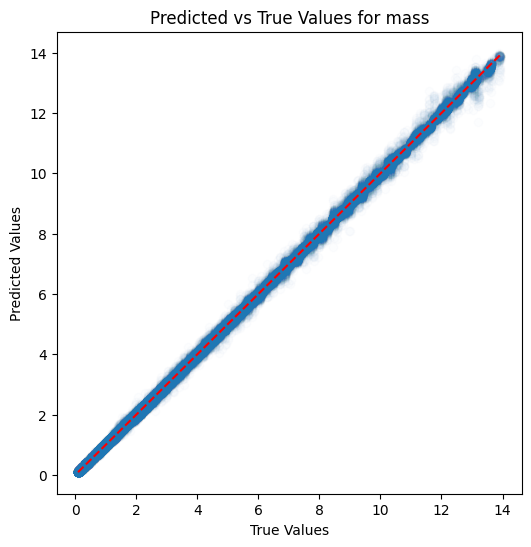

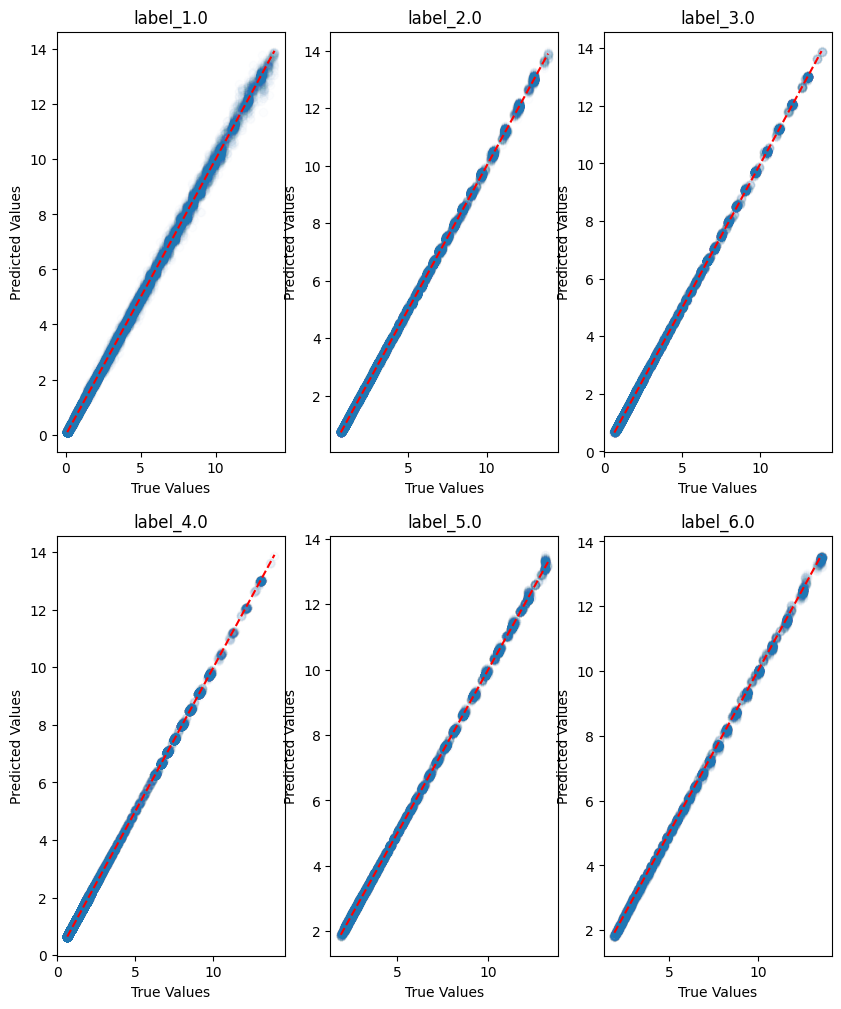

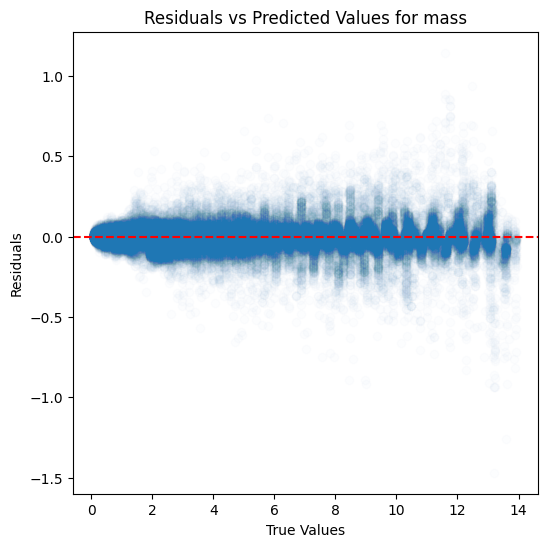

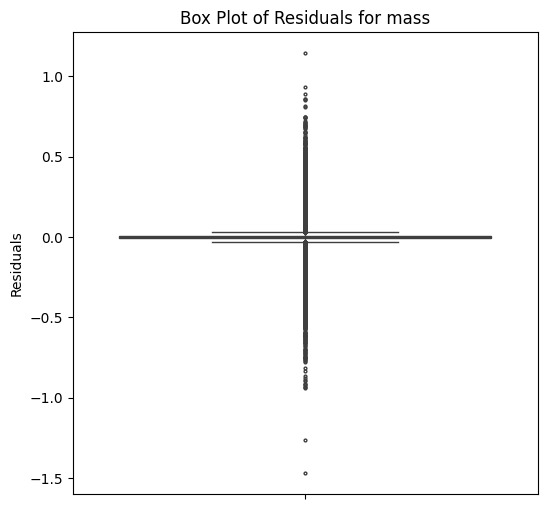

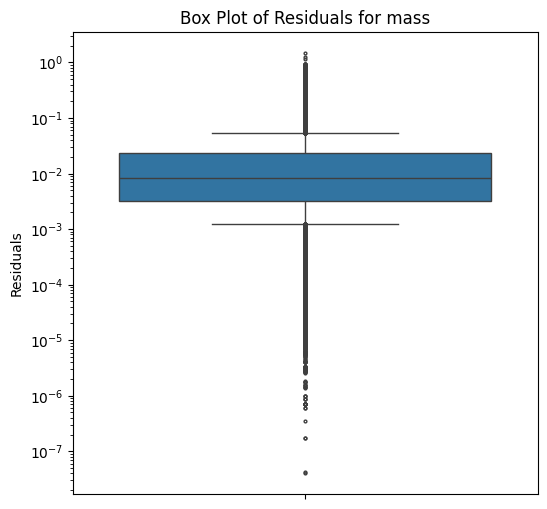

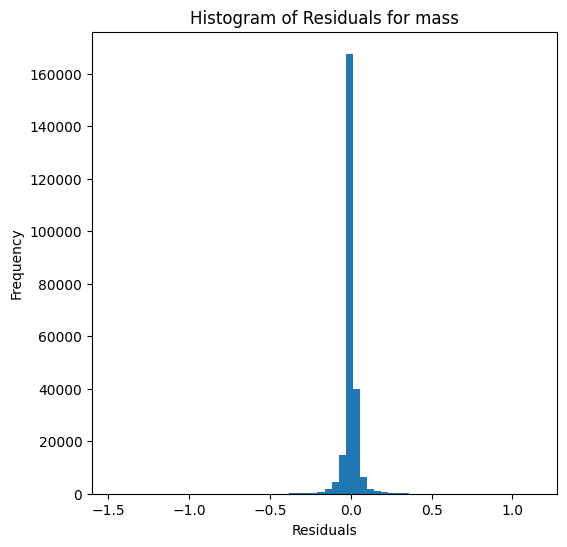

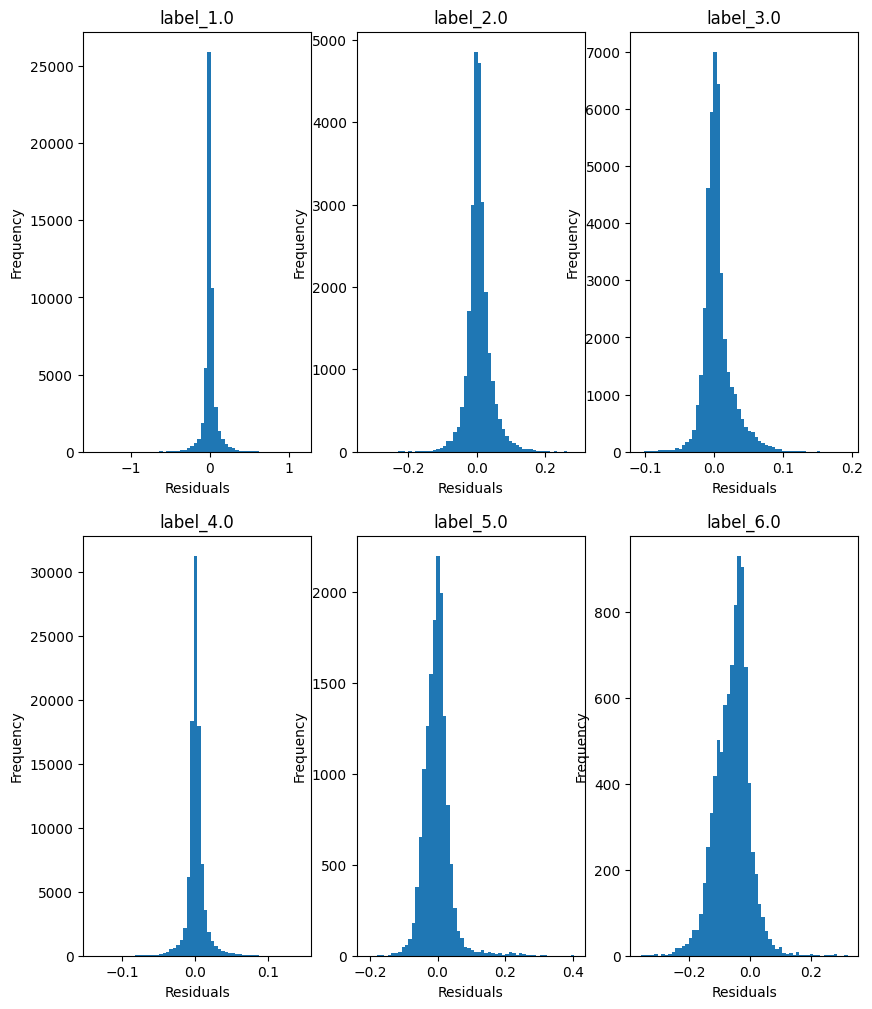

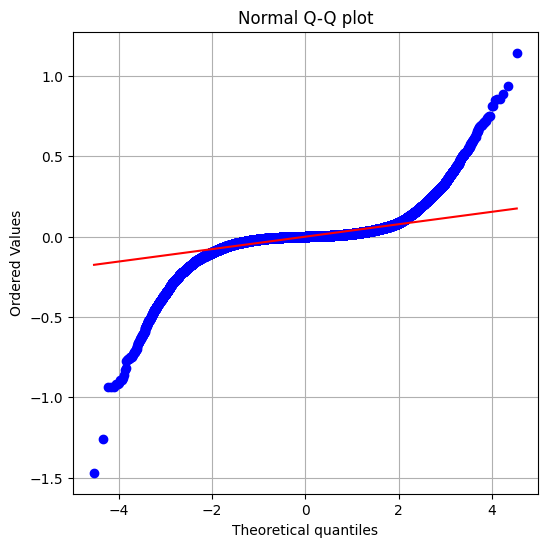

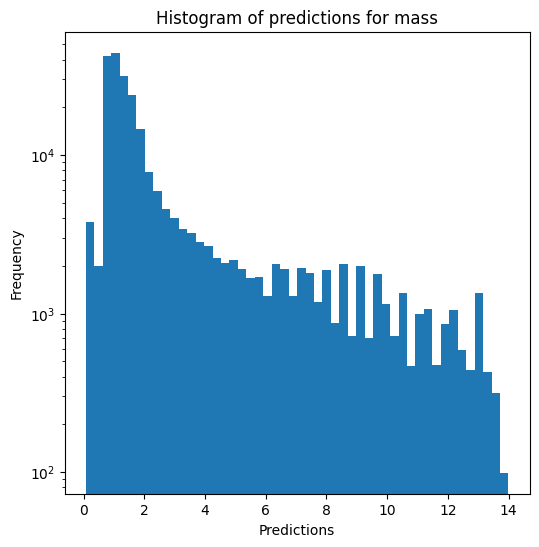

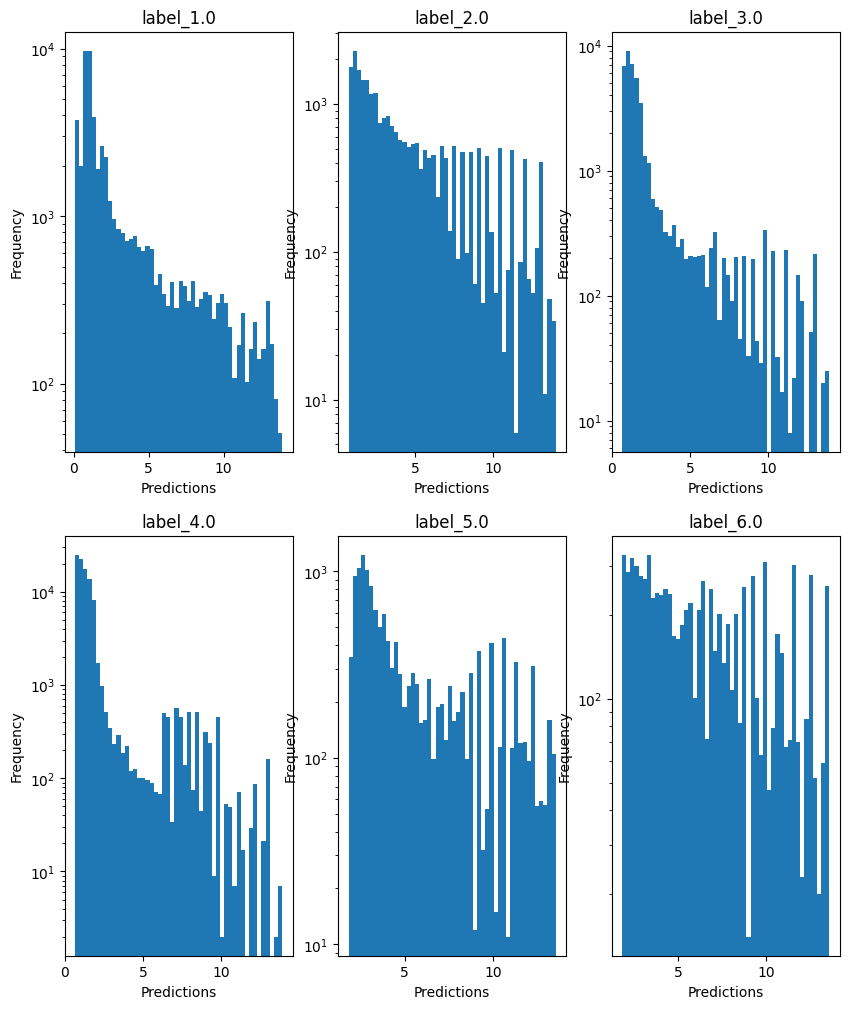

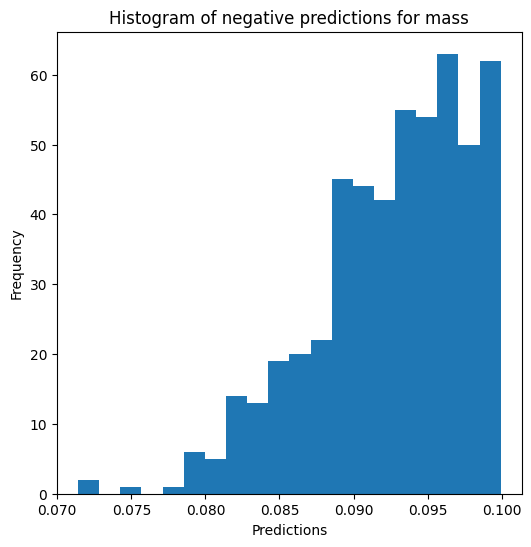


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.99924952821124
  RMSE :  0.010025829454064671
  MAE :  0.006851980137943696
  MedAE :  0.004714362388504166
  CORR :  0.9996247501188131
  MAX_ER :  0.08896295685255406
  Percentiles : 
    75th percentile :  0.009184591126604955
    90th percentile :  0.015166520496588815
    95th percentile :  0.02010547089875027
    99th percentile :  0.03502351341217506

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9994404577145701
  RMSE :  0.01284990524417628
  MAE :  0.009512662463685836
  MedAE :  0.007496822958309862
  CORR :  0.9997269256609371
  MAX_ER :  0.15352155580429705
  Percentiles : 
    75th percentile :  0.013189632936975615
    90th percentile :  0.019703675985482158
    95th percentile :  0.024772533746863855
    99th percentile :  0.03776110700516406

radius results for the 

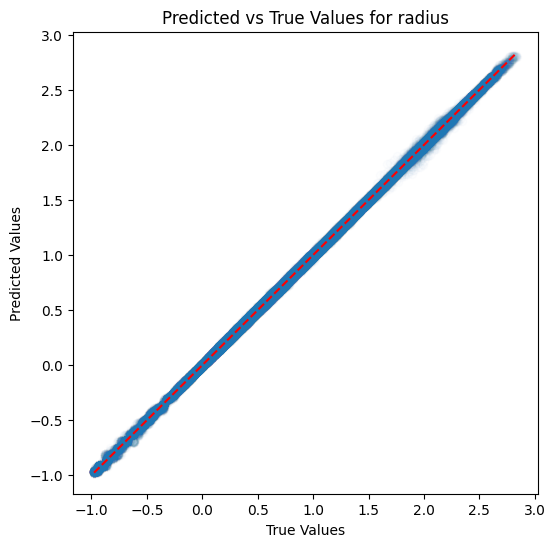

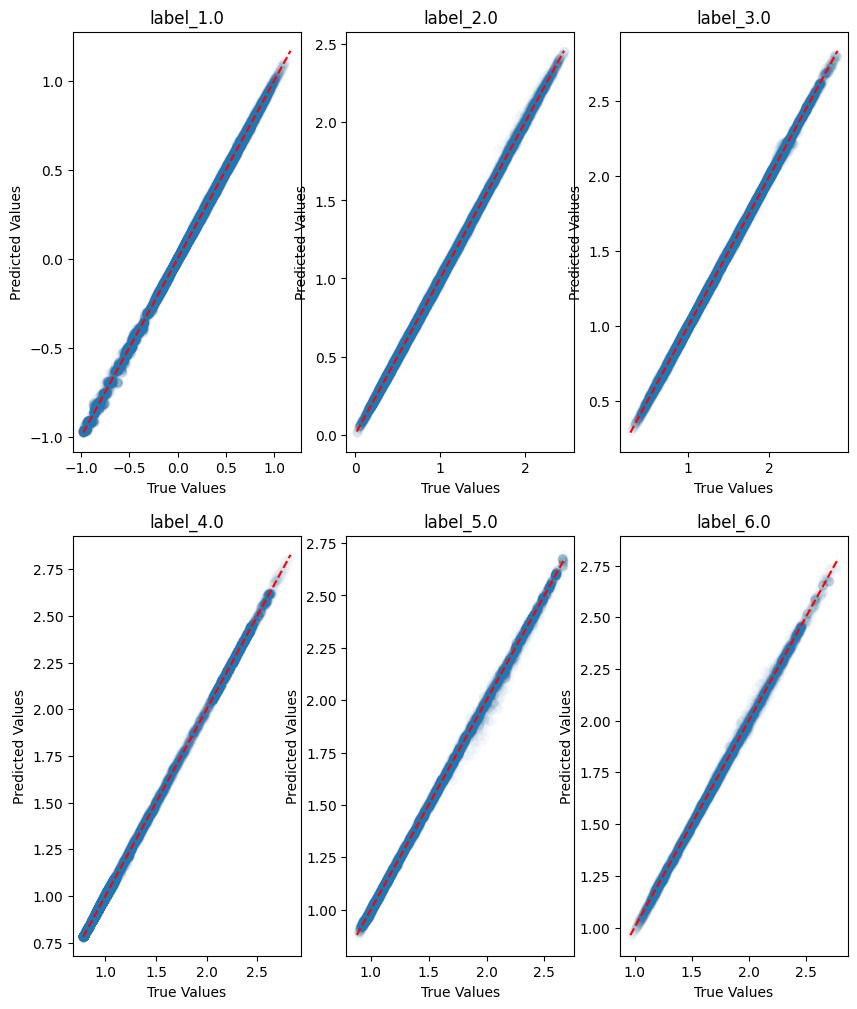

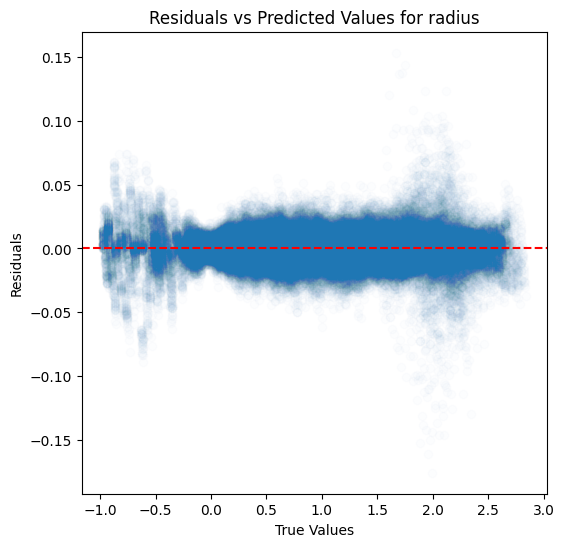

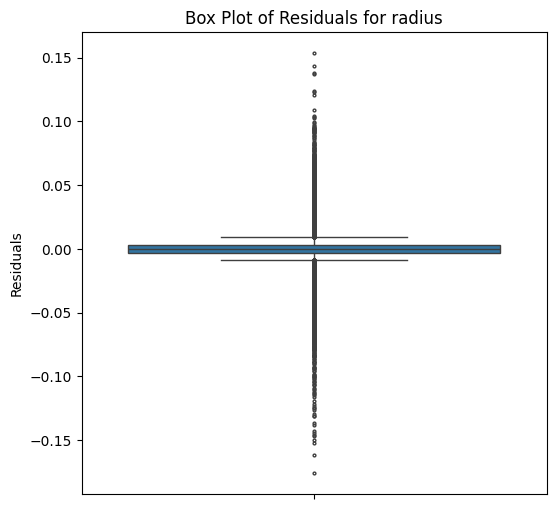

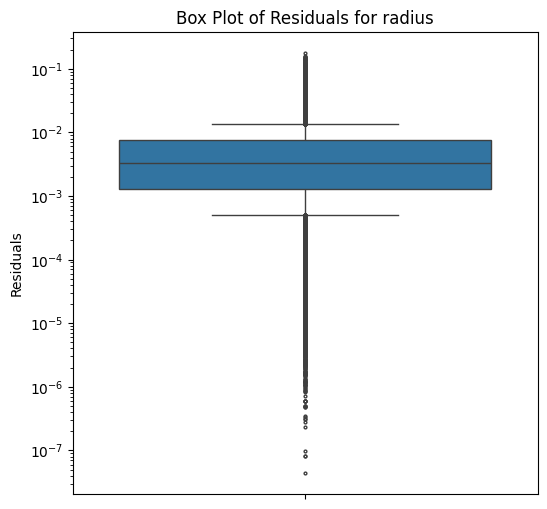

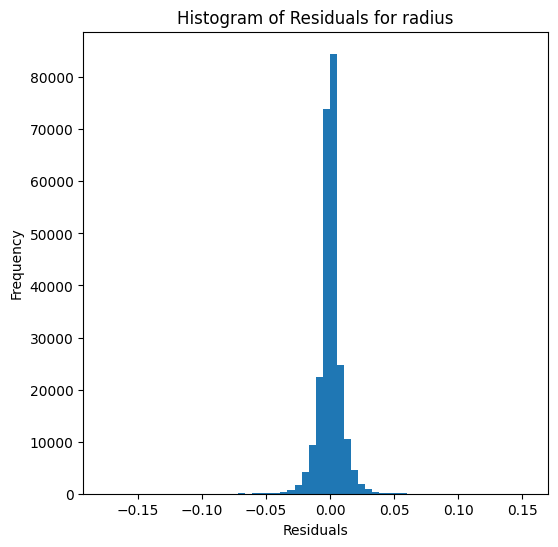

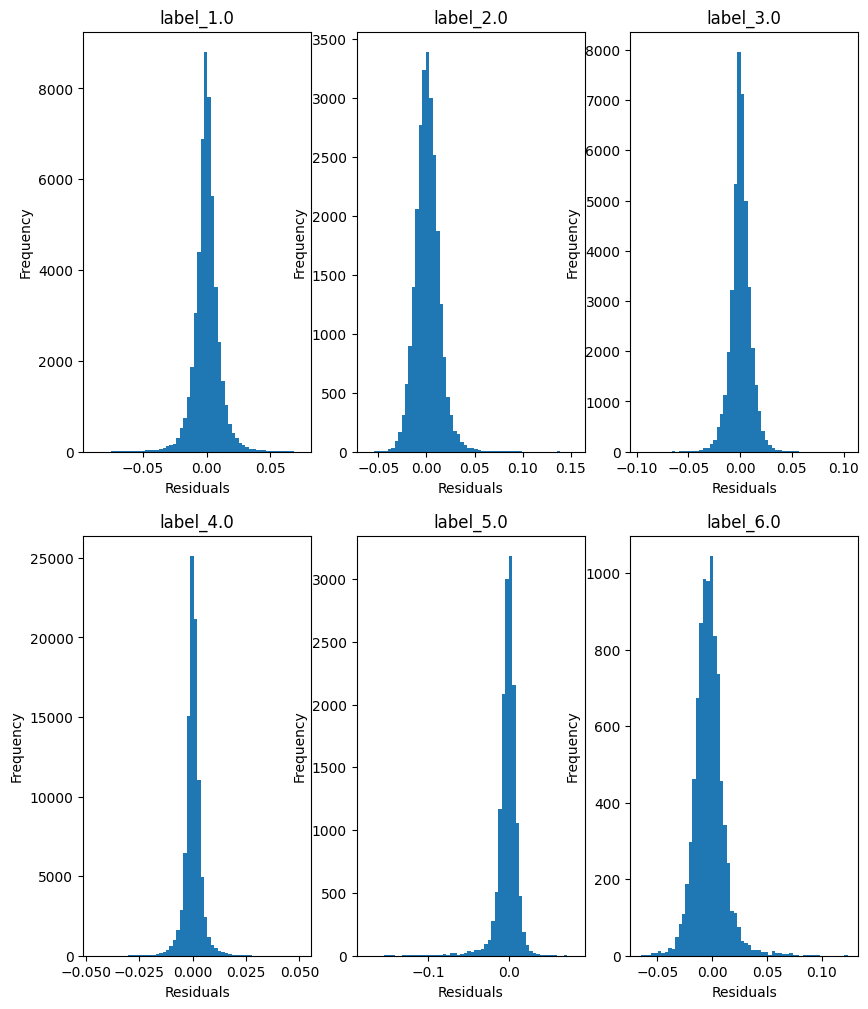

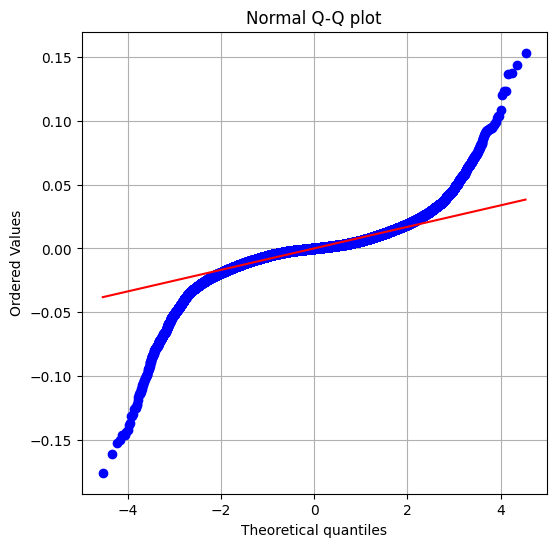

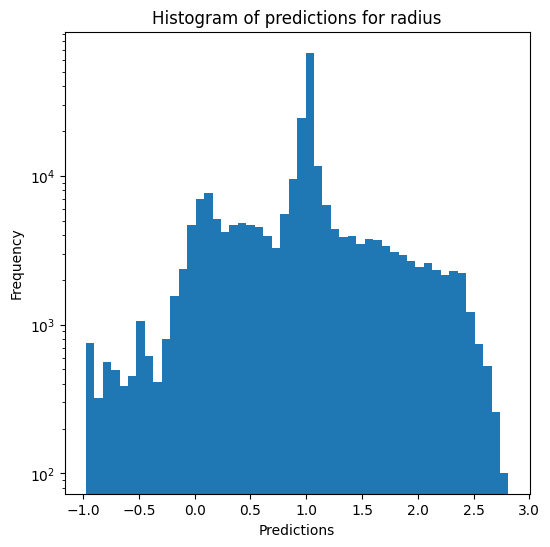

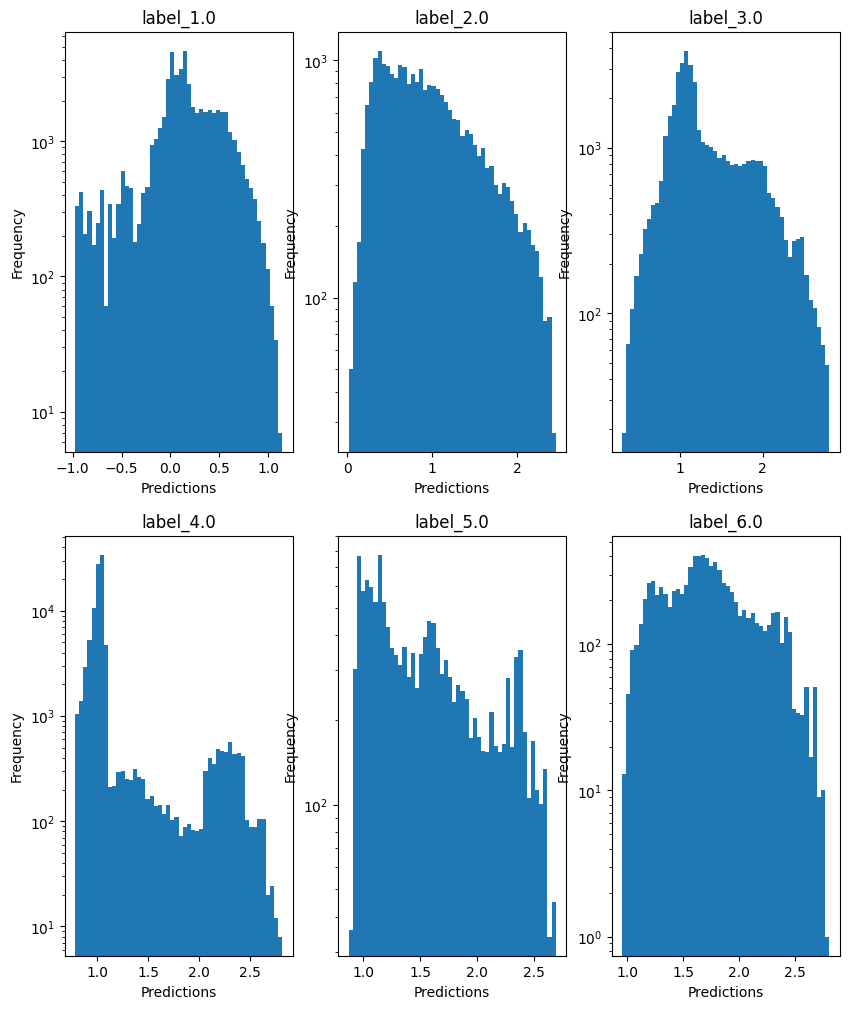

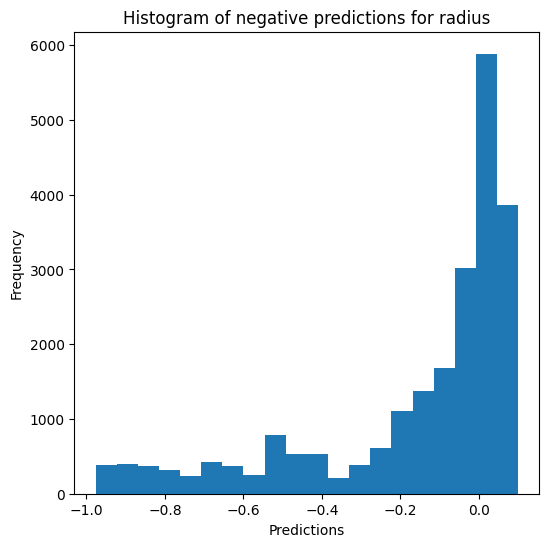

Saving results...


In [18]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [19]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9987502420585099
  RMSE :  0.1072766146118961
  MAE :  0.06114685121302729
  MedAE :  0.03819388341543445
  CORR :  0.9993800839205965
  MAX_ER :  1.4758801510183677
  Percentiles : 
    75th percentile :  0.06654751262256661
    90th percentile :  0.12429927595213375
    95th percentile :  0.1973373997061043
    99th percentile :  0.4688501676610515

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9965617240052644
  RMSE :  0.2079340935215777
  MAE :  0.12130712141410704
  MedAE :  0.058413586733669476
  CORR :  0.9988595292125967
  MAX_ER :  2.13476847638778
  Percentiles : 
    75th percentile :  0.13817420244793566
    90th percentile :  0.33274586420606767
    95th percentile :  0.4624654564618292
    99th percentile :  0.7914733753550216

mass results for the label category with a value o

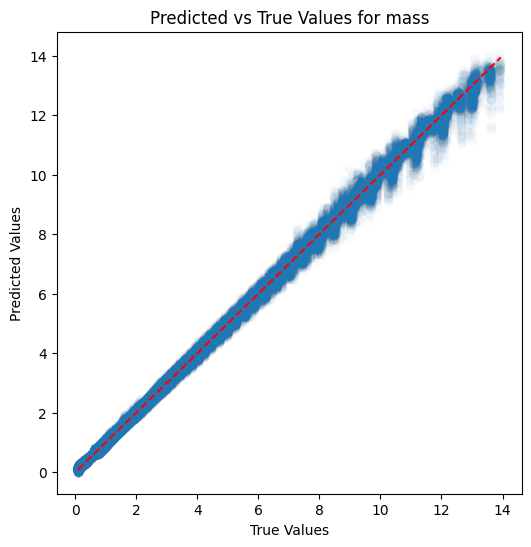

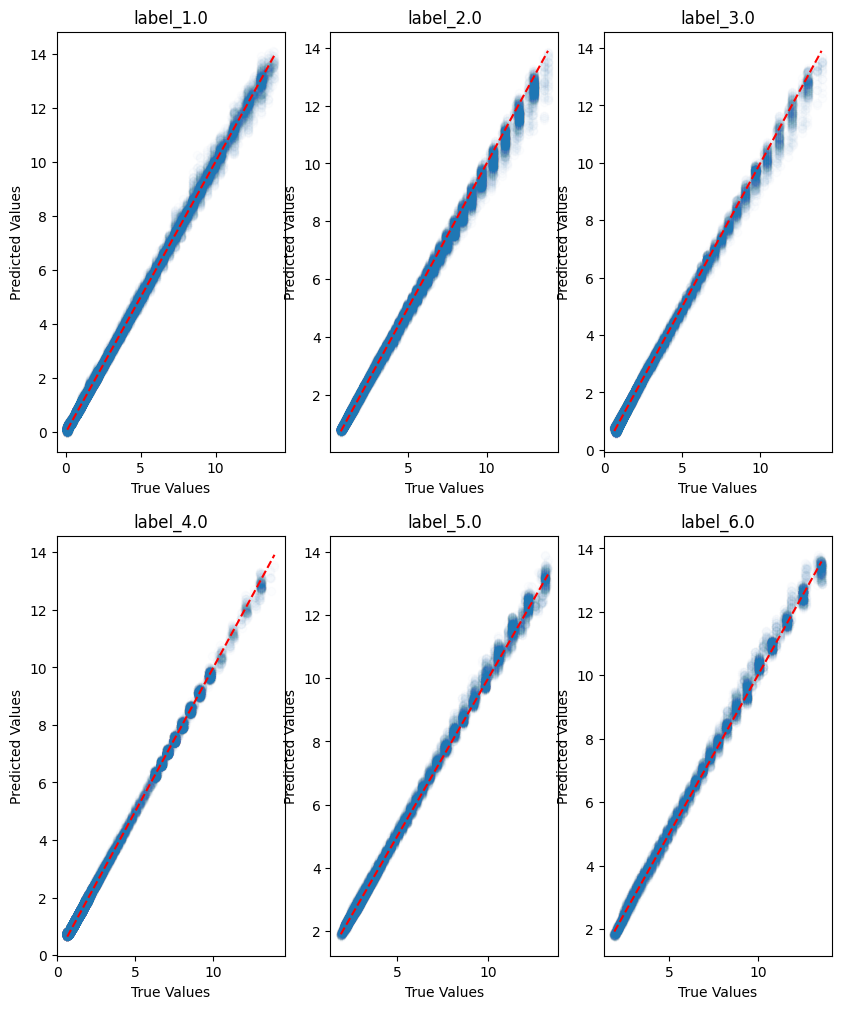

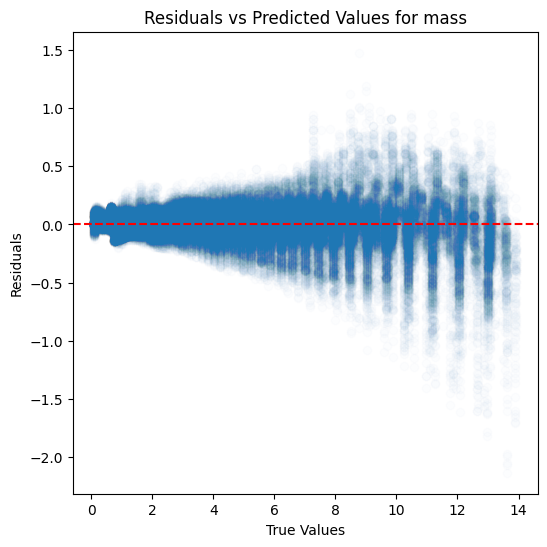

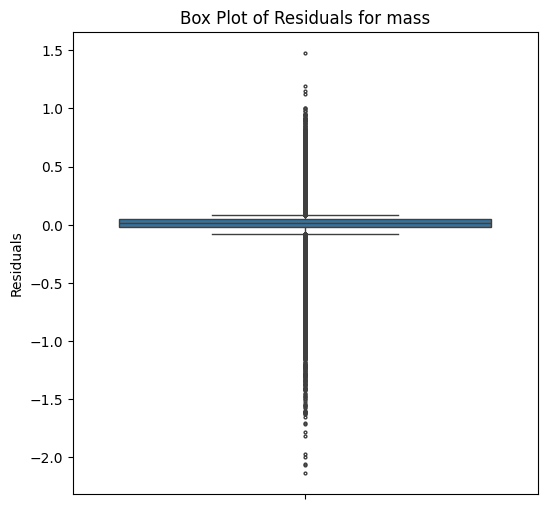

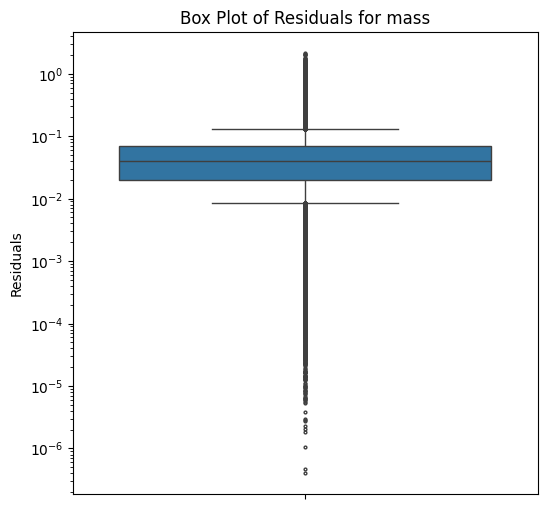

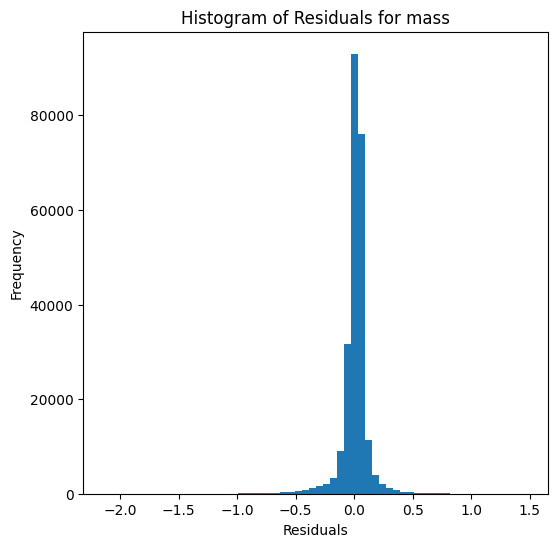

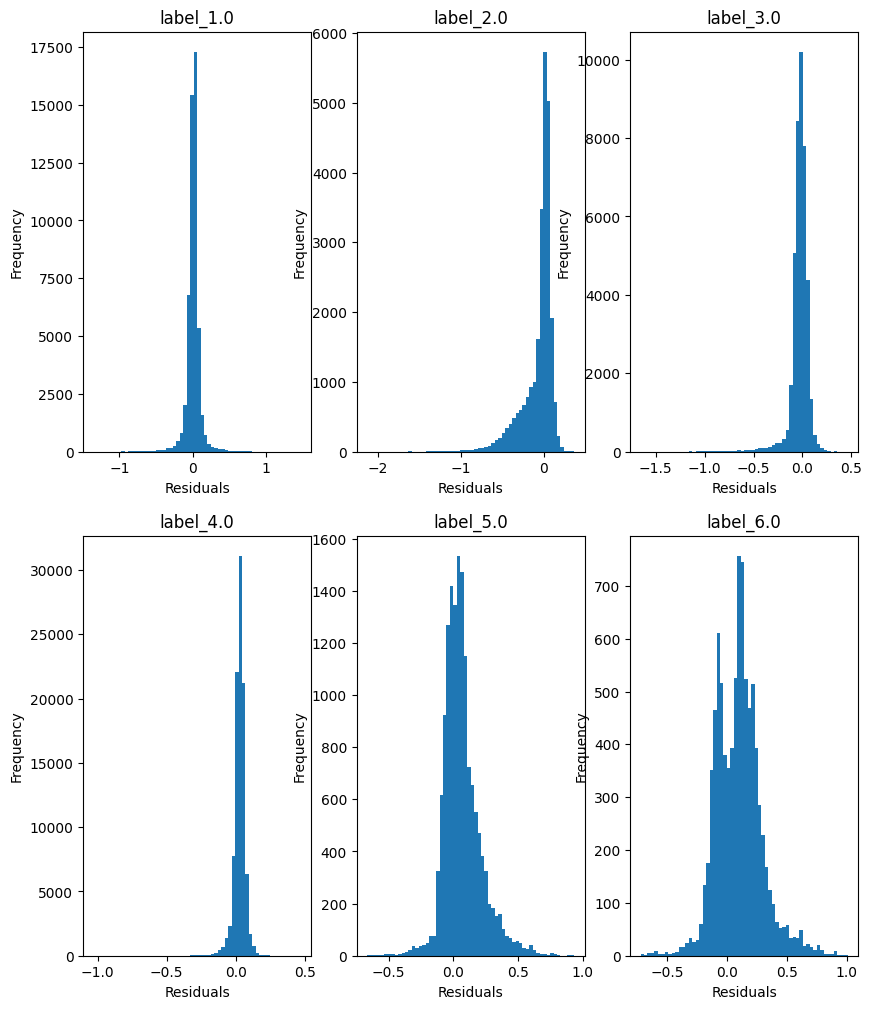

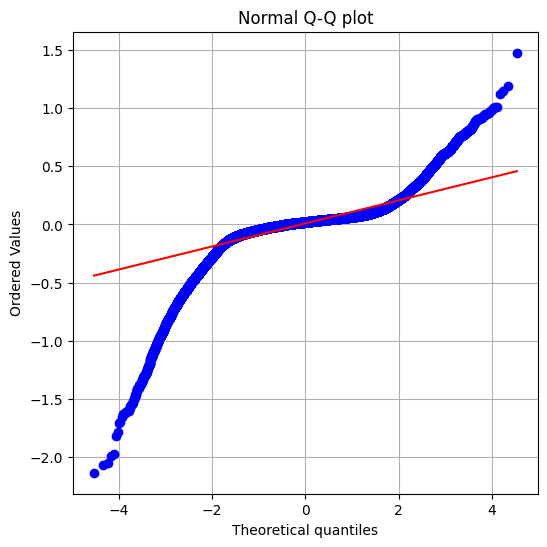

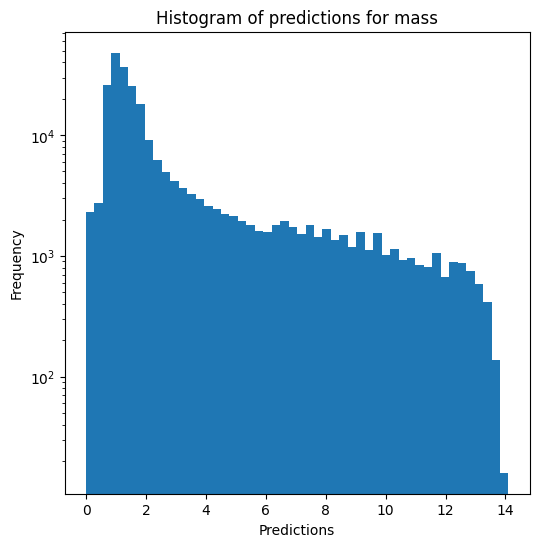

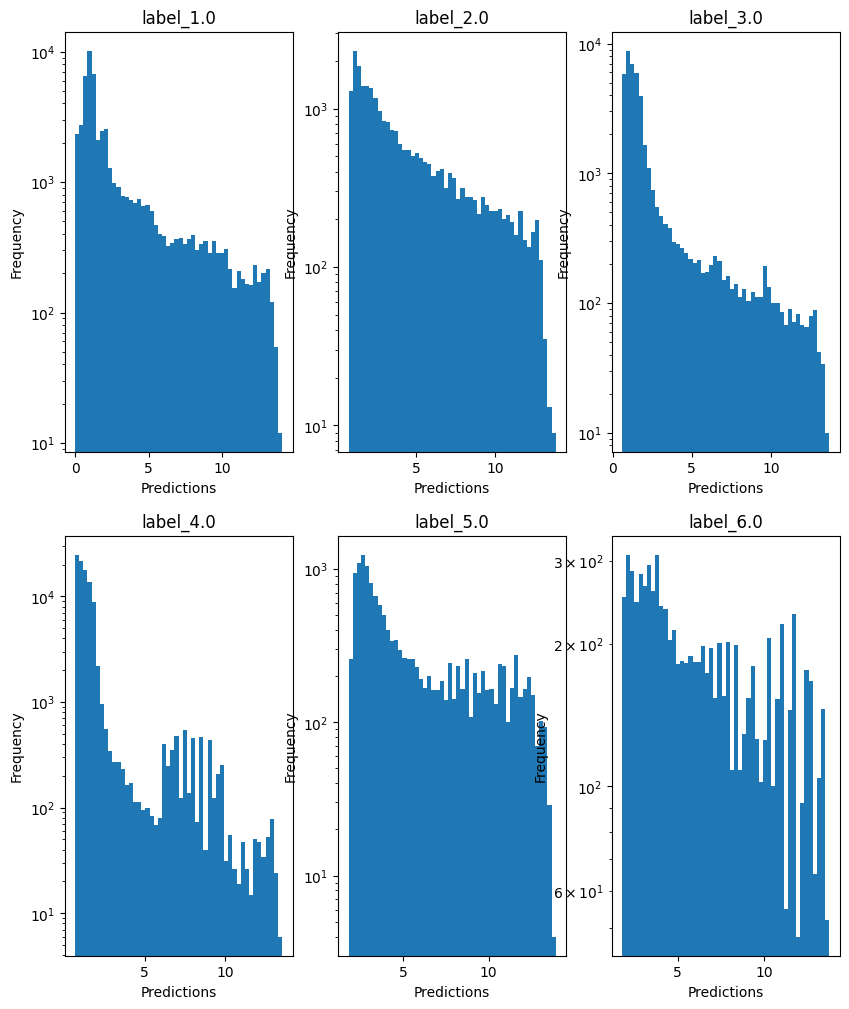

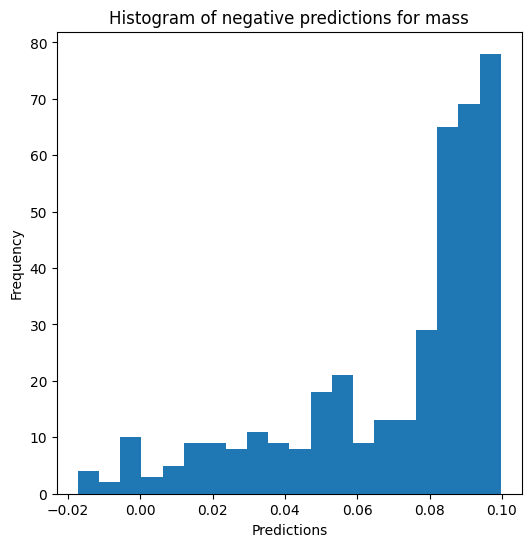


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.1687920203141815
  RVE :  0.9981646611985815
  RMSE :  0.01679691783716148
  MAE :  0.012589885411183529
  MedAE :  0.00968945114626471
  CORR :  0.9991189309824832
  MAX_ER :  0.1561630360672922
  Percentiles : 
    75th percentile :  0.017466580934055377
    90th percentile :  0.026660365332961927
    95th percentile :  0.03380654052106536
    99th percentile :  0.05169535279755309

radius results for the label category with a value of 2.0
  value range :  0.0199466816788423 - 2.458486763798206
  RVE :  0.9986910877477772
  RMSE :  0.019627510651855078
  MAE :  0.015366807848826314
  MedAE :  0.012451057962700351
  CORR :  0.9993723124623445
  MAX_ER :  0.08975244393297599
  Percentiles : 
    75th percentile :  0.021943507103256404
    90th percentile :  0.03284852004683299
    95th percentile :  0.03979932569657089
    99th percentile :  0.051374242861038345

radius results for the l

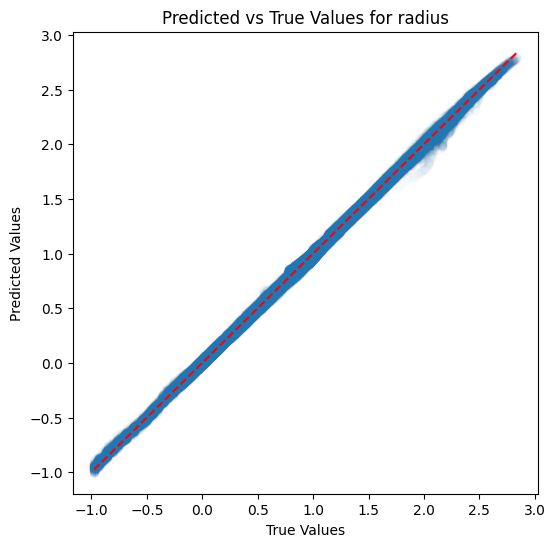

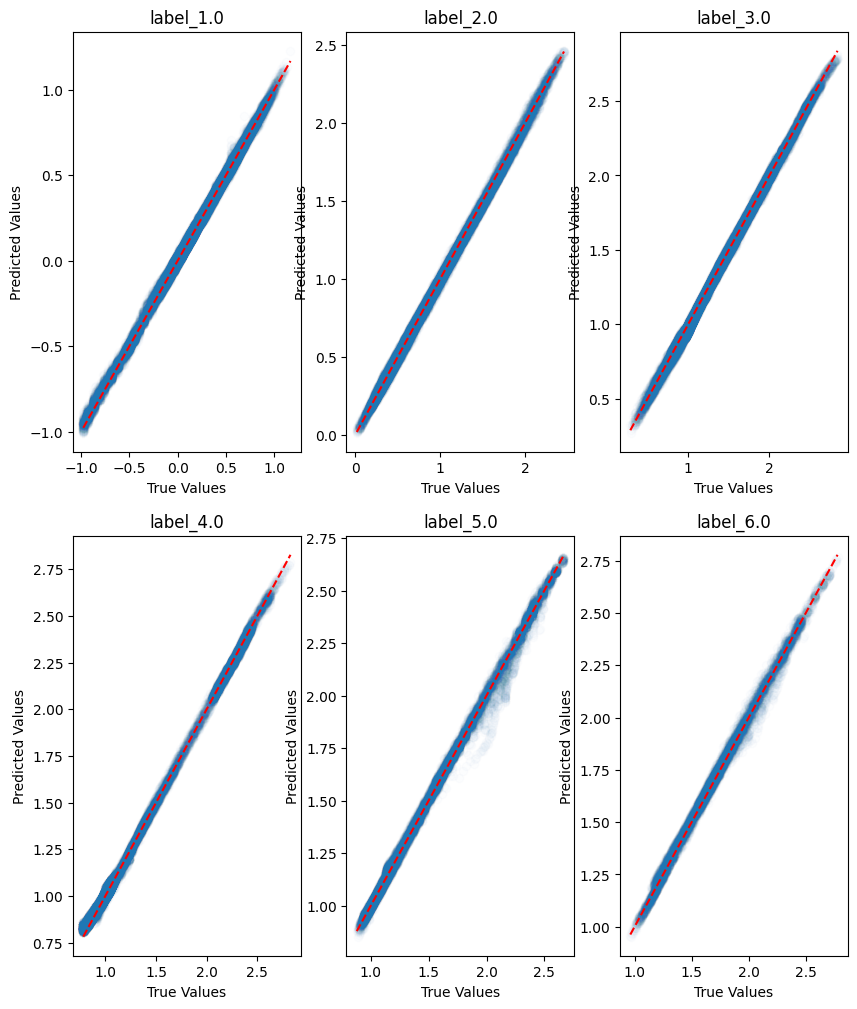

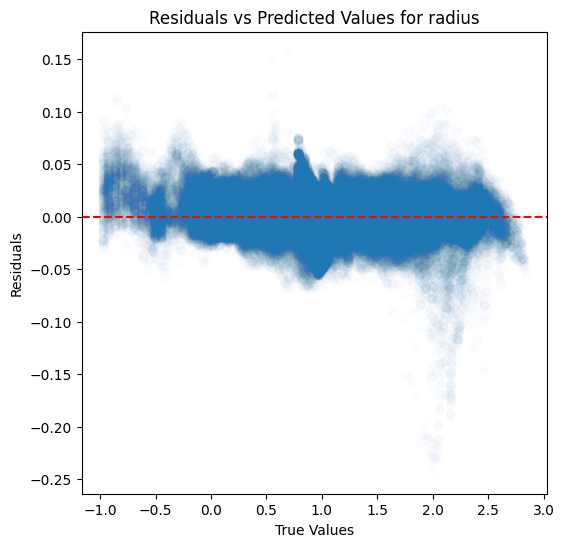

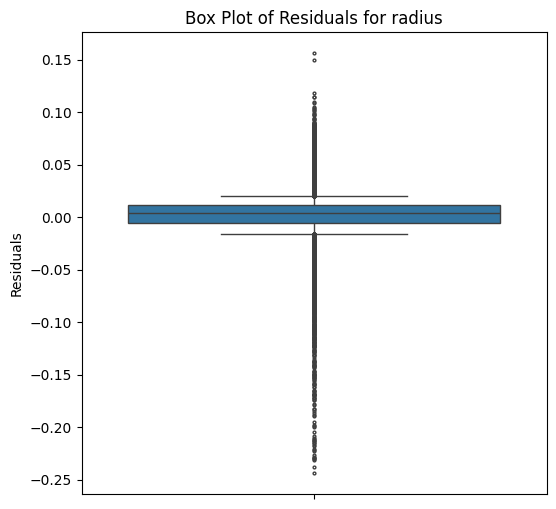

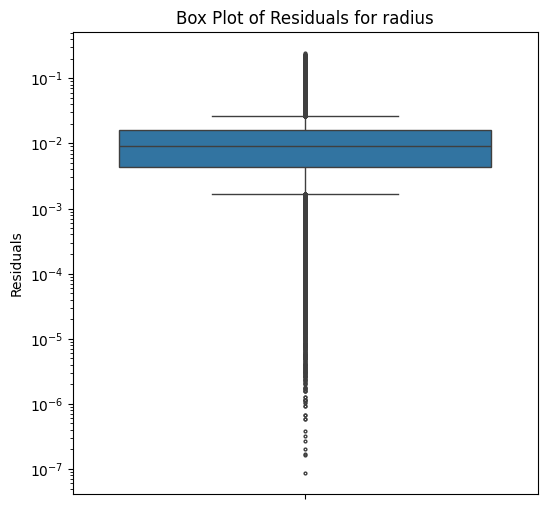

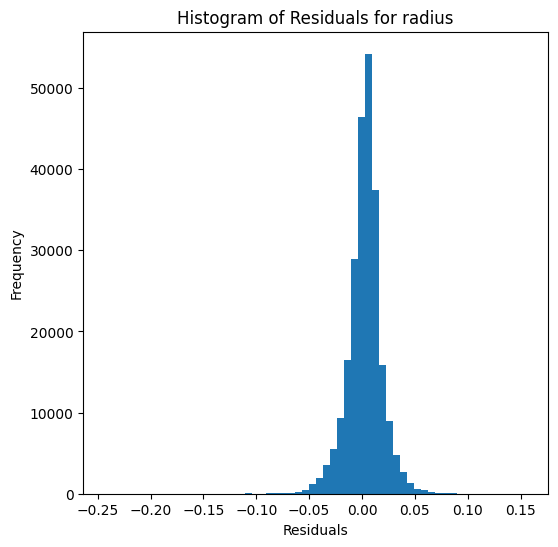

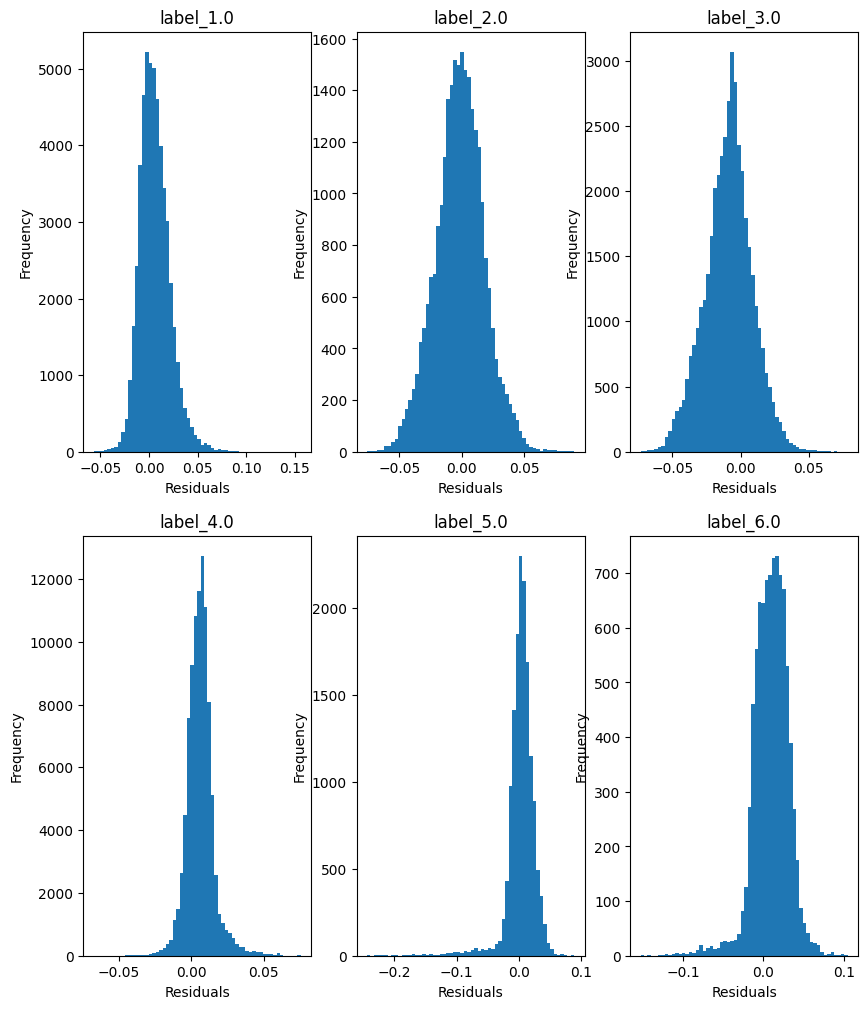

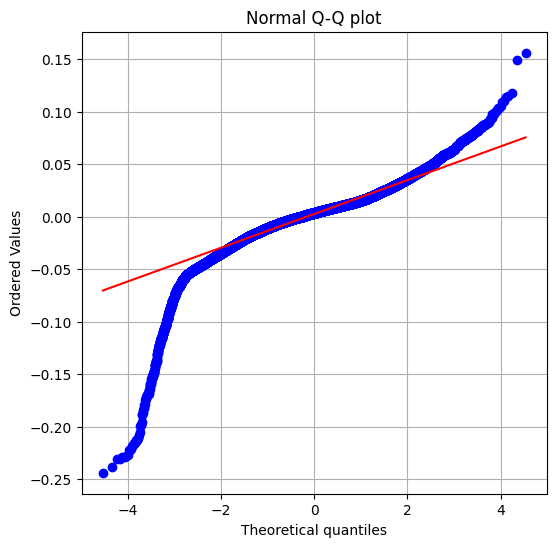

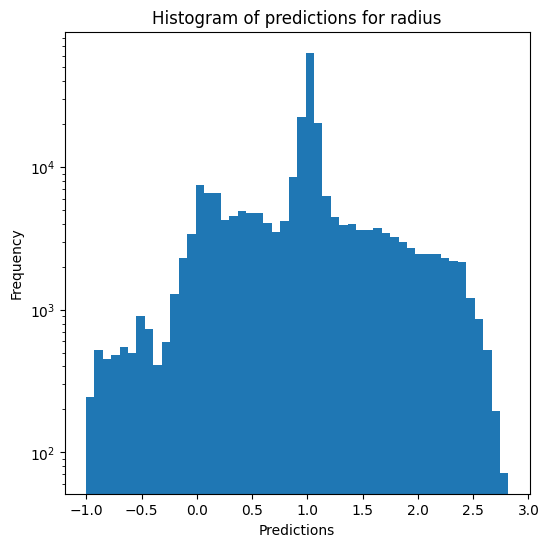

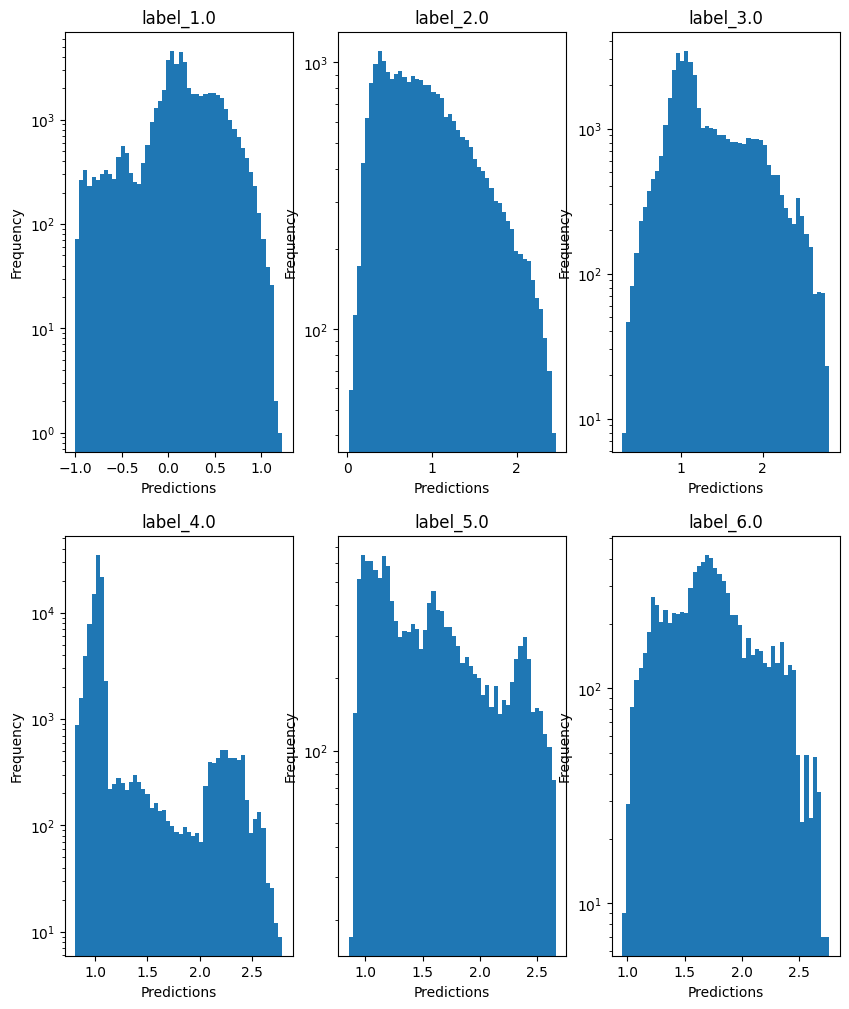

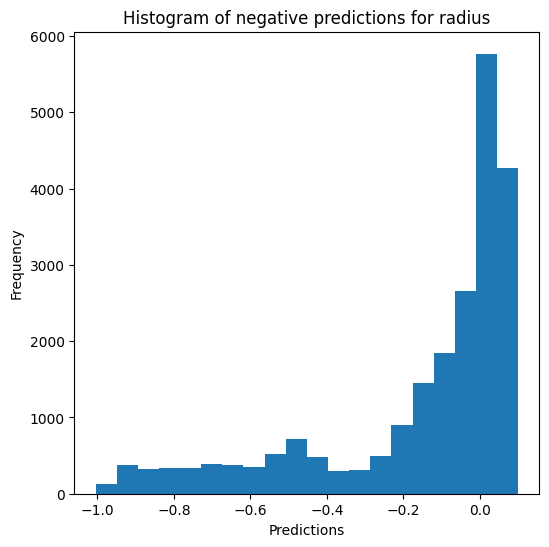

Saving results...


In [20]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)